In [12]:
# ================== Minimal Environment Setup ==================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from pathlib import Path
from scipy.stats import theilslopes
from collections import deque

# --- Core Configuration (Please ensure consistency with your training setup) ---
class Config:
    # Set to True for the script to access logs saved in your Google Drive
    USE_GOOGLE_DRIVE = True
    # This is the path in your Google Drive where results are saved
    DRIVE_PATH = '/content/drive/MyDrive/Colab/VisionTransformer'

cfg = Config()

# --- Environment Setup ---
if cfg.USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUTPUT_ROOT = str(Path(cfg.DRIVE_PATH) / 'outputs')
else:
    OUTPUT_ROOT = './outputs'

print(f"✅ Environment setup complete, logs will be read from: {Path(OUTPUT_ROOT) / 'grid_search'}")

Mounted at /content/drive
✅ Environment setup complete, logs will be read from: /content/drive/MyDrive/Colab/VisionTransformer/outputs/grid_search


In [13]:
# ================== CELL C: Plotting Function Library (Boundary effect of smoothing function fixed) ==================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

# ====== Smoothing function, using pandas.rolling to resolve boundary issues ======
def moving_average(x, w=3):
    """
    Uses pandas.rolling for moving average, which handles boundaries better.
    min_periods=1 ensures that the average is calculated even when the window is incomplete at the edges.
    """
    if x is None: return None
    x_series = pd.Series(x)
    if w is None or w <= 1 or len(x_series) < 2:
        return x_series.values
    return x_series.rolling(window=w, center=True, min_periods=1).mean().values

# ====== Automatically infer epoch axis ======
def _infer_epochs(*series, explicit_epochs=None):
    if explicit_epochs is not None: return np.arange(1, explicit_epochs + 1)
    lengths = [len(s) for s in series if s is not None and hasattr(s, '__len__')]
    if not lengths: raise ValueError("Could not infer epochs")
    n = max(lengths)
    return np.arange(1, n + 1)

# ====== Main three-panel plotting function (now using the new smoothing function) ======
def plot_three_panel_training(
    train_losses=None, val_losses=None, train_accs=None, val_accs=None,
    grad_entropies=None, attn_entropies_avg=None, attn_entropies_per_layer=None,
    smooth_windows=None, show_attn_layers='all', attn_layer_alpha=0.25,
    stage_spans=None, explicit_epochs=None, figsize=(16, 5),
    title="Training Dashboard", save_path=None, save_dpi=150
):
    if smooth_windows is None: sw = {'loss': 1, 'acc': 1, 'entropy': 1}
    elif isinstance(smooth_windows, int): sw = {'loss': smooth_windows, 'acc': smooth_windows, 'entropy': smooth_windows}
    elif isinstance(smooth_windows, dict):
        sw = {'loss': 1, 'acc': 1, 'entropy': 1}; sw.update(smooth_windows)
    else: raise TypeError("smooth_windows must be an int or a dict.")

    epochs_arr = _infer_epochs(train_losses, val_losses, train_accs, val_accs, grad_entropies, attn_entropies_avg, *([] if attn_entropies_per_layer is None else attn_entropies_per_layer), explicit_epochs=explicit_epochs)
    best_epoch, best_vloss = None, None
    if val_losses is not None and len(val_losses) > 0:
        val_losses_np = np.asarray(val_losses, dtype=float)
        best_idx = int(np.argmin(val_losses_np))
        best_epoch, best_vloss = int(epochs_arr[best_idx]), float(val_losses_np[best_idx])

    trL_s = moving_average(train_losses, sw['loss']); vaL_s = moving_average(val_losses, sw['loss'])
    trA_s = moving_average(train_accs, sw['acc']); vaA_s = moving_average(val_accs, sw['acc'])
    gH_s = moving_average(grad_entropies, sw['entropy']); aH_s = moving_average(attn_entropies_avg, sw['entropy'])

    fig, axes = plt.subplots(1, 3, figsize=figsize, sharex=True)
    ax_loss, ax_acc, ax_ent = axes; fig.suptitle(title, fontsize=16)

    # Panel 1: Loss
    if trL_s is not None: ax_loss.plot(epochs_arr[:len(trL_s)], trL_s, color='C0', lw=2, label=f"Train Loss (MA{sw['loss']})")
    if vaL_s is not None: ax_loss.plot(epochs_arr[:len(vaL_s)], vaL_s, color='C1', lw=2, label=f"Val Loss (MA{sw['loss']})")
    if best_epoch is not None:
        ax_loss.axvline(best_epoch, color='gray', ls='--', lw=1, label=f"Best @ Ep {best_epoch}")
        ax_loss.scatter([best_epoch], [best_vloss], color='C1', zorder=5)
    ax_loss.set_title("Loss Curves"); ax_loss.set_ylabel("Loss"); ax_loss.grid(True, alpha=0.3); ax_loss.legend()

    # Panel 2: Accuracy
    if trA_s is not None: ax_acc.plot(epochs_arr[:len(trA_s)], trA_s, color='C2', lw=2, label=f"Train Acc (MA{sw['acc']})")
    if vaA_s is not None: ax_acc.plot(epochs_arr[:len(vaA_s)], vaA_s, color='C3', lw=2, label=f"Val Acc (MA{sw['acc']})")
    if best_epoch is not None: ax_acc.axvline(best_epoch, color='gray', ls='--', lw=1)
    ax_acc.set_ylim(0.0, 1.01); ax_acc.set_title("Accuracy Curves"); ax_acc.set_ylabel("Accuracy"); ax_acc.grid(True, alpha=0.3); ax_acc.legend()

    # Panel 3: Entropies
    ax_ent_r = ax_ent.twinx()
    if gH_s is not None: ax_ent.plot(epochs_arr[:len(gH_s)], gH_s, color='C4', lw=2, label=f"Grad Entropy (MA{sw['entropy']})")
    if aH_s is not None: ax_ent_r.plot(epochs_arr[:len(aH_s)], aH_s, color='C5', lw=2, label=f"Attn Entropy (avg, MA{sw['entropy']})")
    if attn_entropies_per_layer and show_attn_layers:
        layers_to_plot = range(len(attn_entropies_per_layer)) if show_attn_layers == 'all' else list(show_attn_layers)
        for li in layers_to_plot:
            if 0 <= li < len(attn_entropies_per_layer):
                y_s = moving_average(attn_entropies_per_layer[li], sw['entropy'])
                ax_ent_r.plot(epochs_arr[:len(y_s)], y_s, lw=1, alpha=attn_layer_alpha, color='C5')
    if best_epoch is not None: ax_ent.axvline(best_epoch, color='gray', ls='--', lw=1)
    ax_ent.set_title("Entropy Curves"); ax_ent.set_ylabel("Grad Entropy", color='C4'); ax_ent_r.set_ylabel("Attn Entropy", color='C5')
    ax_ent.tick_params(axis='y', labelcolor='C4'); ax_ent_r.tick_params(axis='y', labelcolor='C5')
    lines, labels = ax_ent.get_legend_handles_labels(); lines2, labels2 = ax_ent_r.get_legend_handles_labels()
    ax_ent_r.legend(lines + lines2, labels + labels2, loc='best')

    for ax in axes: ax.set_xlabel("Epoch")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    if save_path: plt.savefig(save_path, dpi=save_dpi, bbox_inches="tight"); print(f"[FIG] saved to {save_path}")
    plt.show()

# ====== Attention Entropy Detail Plotting Function (now using the new smoothing function) ======
def plot_attention_entropy_details(
    attn_entropies_avg=None, attn_entropies_per_layer=None,
    avg_of_layers=None, smooth_window=3,
    title="Attention Entropy Details", save_path=None, save_dpi=150
):
    if attn_entropies_per_layer is None:
        print("No per-layer attention entropy data provided.")
        return

    epochs_arr = _infer_epochs(attn_entropies_avg, *attn_entropies_per_layer)
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))

    for i, layer_entropy in enumerate(attn_entropies_per_layer):
        y_s = moving_average(layer_entropy, smooth_window)
        ax.plot(epochs_arr[:len(y_s)], y_s, alpha=0.4, label=f"Layer {i+1}")

    if attn_entropies_avg is not None:
        avg_s = moving_average(attn_entropies_avg, smooth_window)
        ax.plot(epochs_arr[:len(avg_s)], avg_s, color='black', lw=2.5, ls='--', label='Global Average')

    if avg_of_layers is not None:
        selected_layers_data = []
        valid_layers = []
        for layer_idx in avg_of_layers:
            if 0 <= layer_idx < len(attn_entropies_per_layer):
                selected_layers_data.append(attn_entropies_per_layer[layer_idx])
                valid_layers.append(layer_idx + 1)
        if selected_layers_data:
            selected_avg = np.mean(selected_layers_data, axis=0)
            selected_avg_s = moving_average(selected_avg, smooth_window)
            ax.plot(epochs_arr[:len(selected_avg_s)], selected_avg_s, color='red', lw=2.5, label=f'Avg of Layers {valid_layers}')

    ax.set_title(title, fontsize=16)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Attention Entropy")
    ax.grid(True, alpha=0.3)
    ax.legend(title="Attention Layers", bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=save_dpi, bbox_inches="tight"); print(f"[FIG] saved to {save_path}")
    plt.show()

print("Plotting function library loaded.")


Plotting function library loaded.


Loading log file: /content/drive/MyDrive/Colab/VisionTransformer/outputs/grid_search/D_mnist_M_M_Light_S_42_logs.csv
✅ File loaded successfully, starting plot...


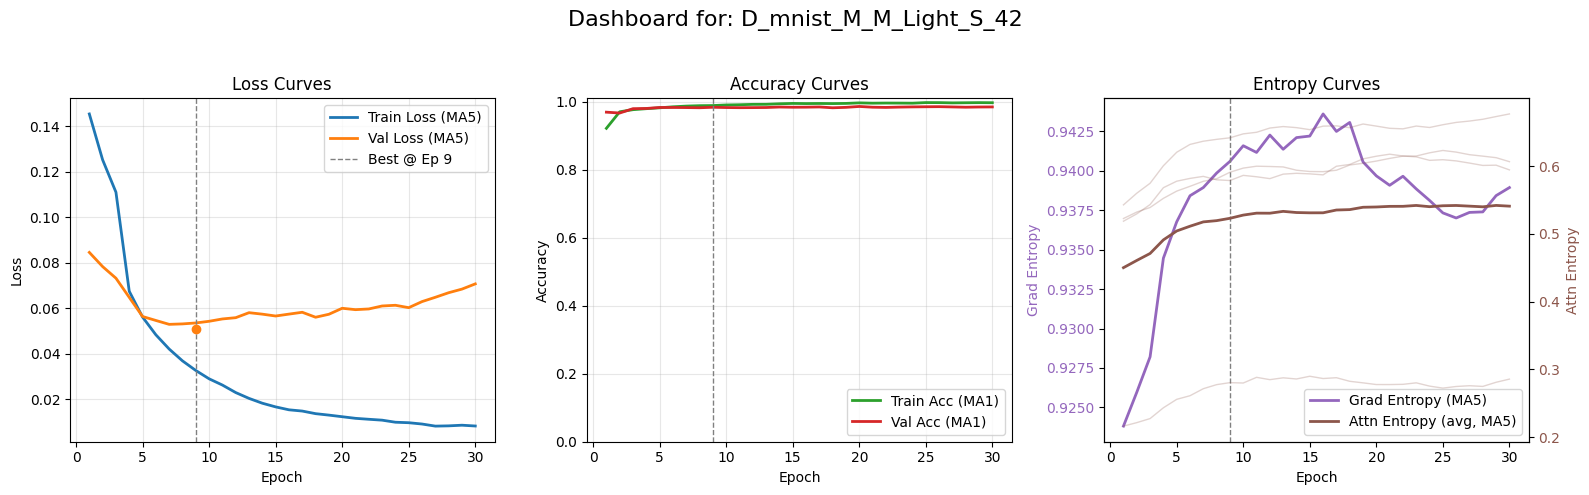

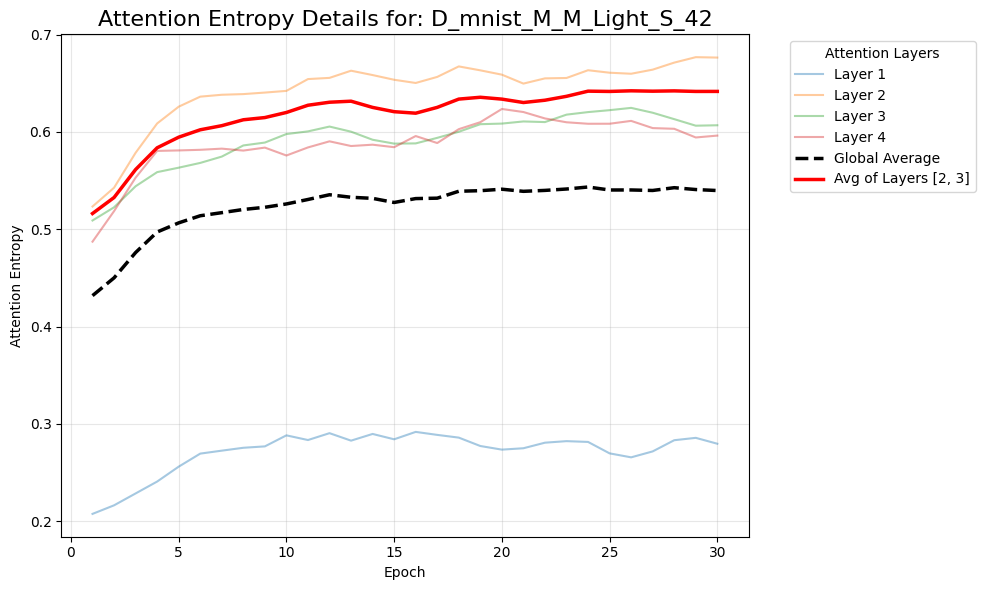

In [14]:
# ================== Plotting Driver ==================

# --- 1. Experiment to visualize ---
DATASET = "mnist"      # 'mnist', 'cifar10', 'cifar100'
MODEL_TYPE = "M_Light"     # 'M_Light', 'M_Base', 'M_Deep', 'M_Wide'
SEED = 42
OPTIMIZER = "Adam_noWD"   # 'Adam_noWD', 'Adam_WD',


# --- 2. Automatically load and parse log file ---

experiment_stem = ""
# Check if it's the original Adam experiment without an optimizer label
if OPTIMIZER == 'Adam_noWD':
    experiment_stem = f"D_{DATASET}_M_{MODEL_TYPE}_S_{SEED}"
else:
    # For all other optimizers, use the format with 'O' label
    experiment_stem = f"D_{DATASET}_M_{MODEL_TYPE}_O_{OPTIMIZER}_S_{SEED}"

filename = f"{experiment_stem}_logs.csv"
log_path = Path(OUTPUT_ROOT) / "grid_search" / filename

print(f"Loading log file: {log_path}")

try:
    df = pd.read_csv(log_path)
    print("✅ File loaded successfully, starting plot...")

    # Extract data series from DataFrame
    train_losses = df['train_loss'].values; val_losses = df['val_loss'].values
    train_accs = df['train_acc'].values; val_accs = df['val_acc'].values
    grad_entropies = df['grad_entropy'].values; attn_entropies_avg = df['attn_entropy_avg'].values
    attn_layer_cols = sorted([col for col in df.columns if 'attn_entropy_layer_' in col])
    attn_entropies_per_layer = [df[col].values for col in attn_layer_cols]

    # --- 3. Call plotting functions ---

    # Assume plot_three_panel_training and plot_attention_entropy_details functions are already defined in your environment

    plot_three_panel_training(
        train_losses=train_losses, val_losses=val_losses,
        train_accs=train_accs, val_accs=val_accs,
        grad_entropies=grad_entropies,
        attn_entropies_avg=attn_entropies_avg,
        attn_entropies_per_layer=attn_entropies_per_layer,
        smooth_windows={'loss': 5, 'acc': 1, 'entropy': 5},
        title=f"Dashboard for: {experiment_stem}"
    )

    plot_attention_entropy_details(
        attn_entropies_avg=attn_entropies_avg,
        attn_entropies_per_layer=attn_entropies_per_layer,
        smooth_window=3,
        avg_of_layers=(1, 2), # Example
        title=f"Attention Entropy Details for: {experiment_stem}"
    )

except FileNotFoundError:
    print(f"❌ Error: Log file not found! Please confirm the configuration above is correct.")
    print(f"   - The script is looking for this file: {log_path.name}")
except Exception as e:
    print(f"❌ An unknown error occurred: {e}")

Loading log file: /content/drive/MyDrive/Colab/VisionTransformer/outputs/grid_search/D_mnist_M_M_Light_O_Adam_WD_S_42_logs.csv
✅ File loaded successfully, starting plot...


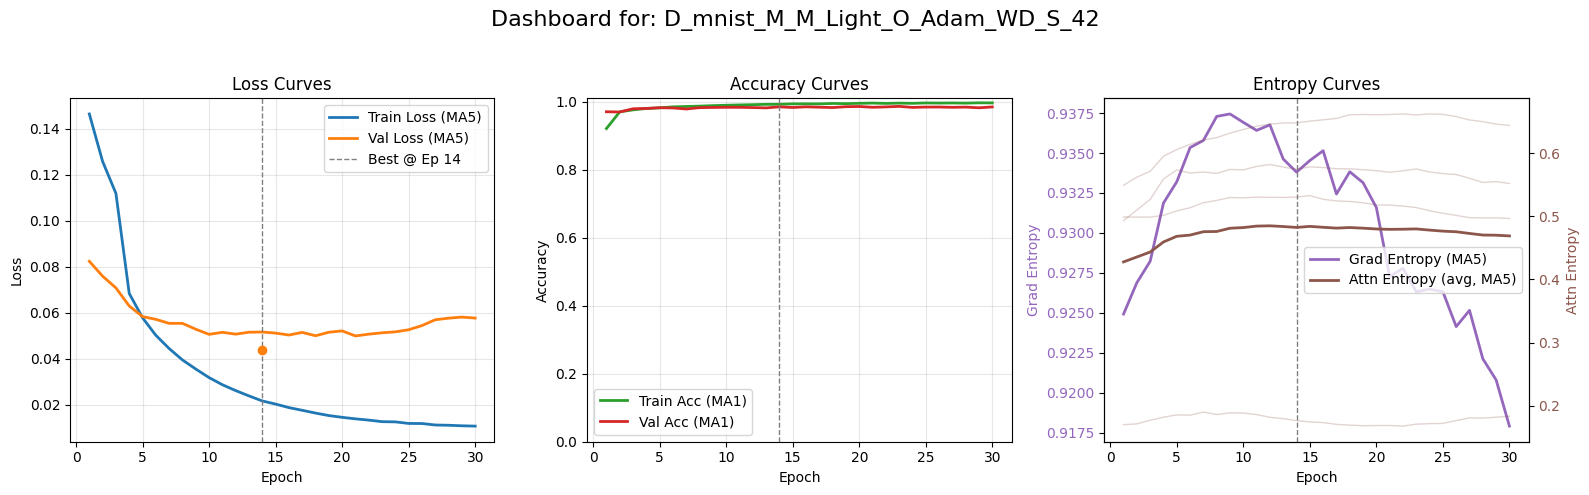

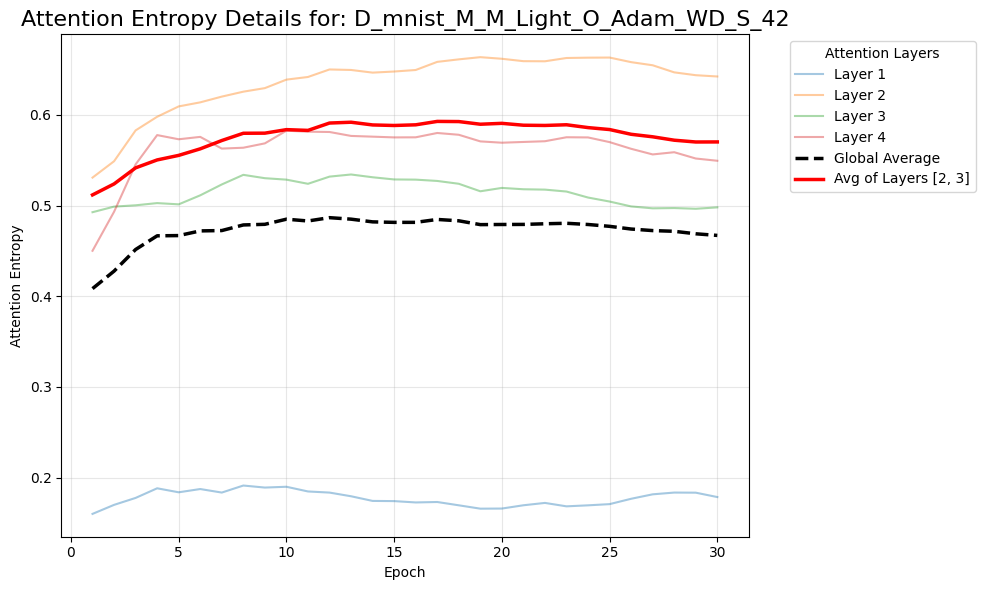

In [15]:
# ================== Plotting Driver ==================

# --- 1. Experiment to visualize ---
DATASET = "mnist"      # 'mnist', 'cifar10', 'cifar100'
MODEL_TYPE = "M_Light"     # 'M_Light', 'M_Base', 'M_Deep', 'M_Wide'
SEED = 42
OPTIMIZER = "Adam_WD"   # 'Adam_noWD', 'Adam_WD',


# --- 2. Automatically load and parse log file ---

experiment_stem = ""
# Check if it's the original Adam experiment without an optimizer label
if OPTIMIZER == 'Adam_noWD':
    experiment_stem = f"D_{DATASET}_M_{MODEL_TYPE}_S_{SEED}"
else:
    # For all other optimizers, use the format with 'O' label
    experiment_stem = f"D_{DATASET}_M_{MODEL_TYPE}_O_{OPTIMIZER}_S_{SEED}"

filename = f"{experiment_stem}_logs.csv"
log_path = Path(OUTPUT_ROOT) / "grid_search" / filename

print(f"Loading log file: {log_path}")

try:
    df = pd.read_csv(log_path)
    print("✅ File loaded successfully, starting plot...")

    # Extract data series from DataFrame
    train_losses = df['train_loss'].values; val_losses = df['val_loss'].values
    train_accs = df['train_acc'].values; val_accs = df['val_acc'].values
    grad_entropies = df['grad_entropy'].values; attn_entropies_avg = df['attn_entropy_avg'].values
    attn_layer_cols = sorted([col for col in df.columns if 'attn_entropy_layer_' in col])
    attn_entropies_per_layer = [df[col].values for col in attn_layer_cols]

    # --- 3. Call plotting functions ---

    # Assume plot_three_panel_training and plot_attention_entropy_details functions are already defined in your environment

    plot_three_panel_training(
        train_losses=train_losses, val_losses=val_losses,
        train_accs=train_accs, val_accs=val_accs,
        grad_entropies=grad_entropies,
        attn_entropies_avg=attn_entropies_avg,
        attn_entropies_per_layer=attn_entropies_per_layer,
        smooth_windows={'loss': 5, 'acc': 1, 'entropy': 5},
        title=f"Dashboard for: {experiment_stem}"
    )

    plot_attention_entropy_details(
        attn_entropies_avg=attn_entropies_avg,
        attn_entropies_per_layer=attn_entropies_per_layer,
        smooth_window=3,
        avg_of_layers=(1, 2), # Example
        title=f"Attention Entropy Details for: {experiment_stem}"
    )

except FileNotFoundError:
    print(f"❌ Error: Log file not found! Please confirm the configuration above is correct.")
    print(f"   - The script is looking for this file: {log_path.name}")
except Exception as e:
    print(f"❌ An unknown error occurred: {e}")

Loading log file: /content/drive/MyDrive/Colab/VisionTransformer/outputs/grid_search/D_mnist_M_M_Wide_S_16_logs.csv
✅ File loaded successfully, starting plot...


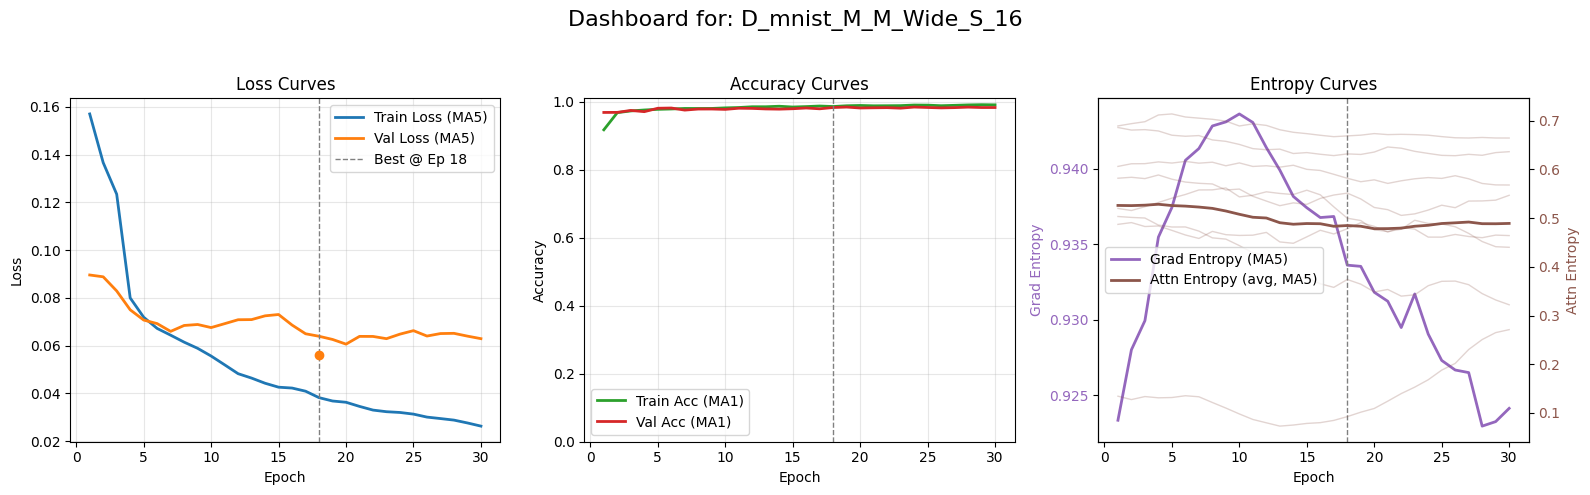

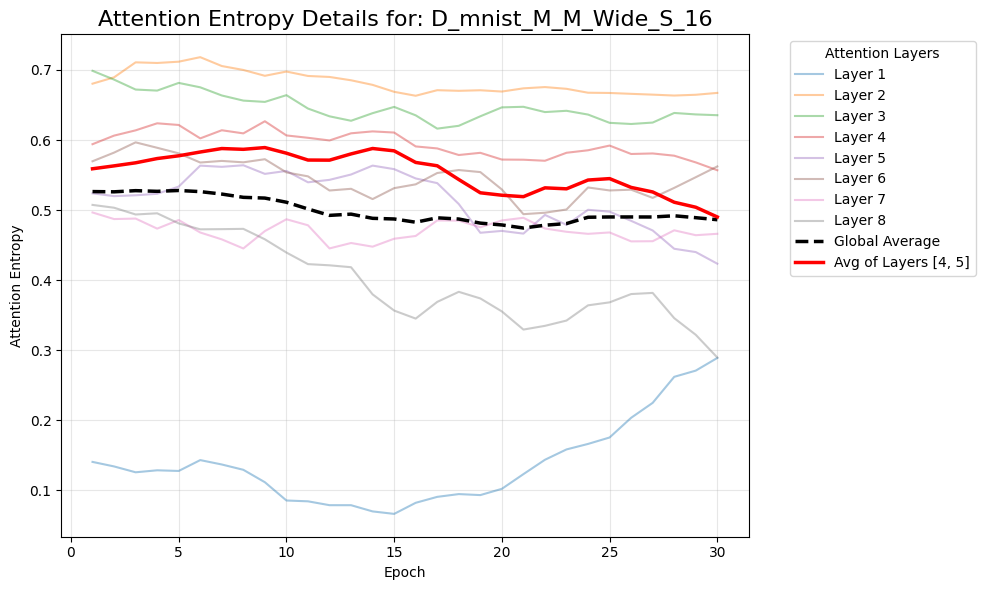

In [16]:
# ================== Plotting Driver ==================

### Wider models that converge later
# --- 1. Experiment to visualize ---
DATASET = "mnist"      # 'mnist', 'cifar10', 'cifar100'
MODEL_TYPE = "M_Wide"     # 'M_Light', 'M_Base', 'M_Deep', 'M_Wide'
SEED = 16
OPTIMIZER = "Adam_noWD"   # 'Adam_noWD', 'Adam_WD',


# --- 2. Automatically load and parse log file ---

experiment_stem = ""
# Check if it's the original Adam experiment without an optimizer label
if OPTIMIZER == 'Adam_noWD':
    experiment_stem = f"D_{DATASET}_M_{MODEL_TYPE}_S_{SEED}"
else:
    # For all other optimizers, use the format with 'O' label
    experiment_stem = f"D_{DATASET}_M_{MODEL_TYPE}_O_{OPTIMIZER}_S_{SEED}"

filename = f"{experiment_stem}_logs.csv"
log_path = Path(OUTPUT_ROOT) / "grid_search" / filename

print(f"Loading log file: {log_path}")

try:
    df = pd.read_csv(log_path)
    print("✅ File loaded successfully, starting plot...")

    # Extract data series from DataFrame
    train_losses = df['train_loss'].values; val_losses = df['val_loss'].values
    train_accs = df['train_acc'].values; val_accs = df['val_acc'].values
    grad_entropies = df['grad_entropy'].values; attn_entropies_avg = df['attn_entropy_avg'].values
    attn_layer_cols = sorted([col for col in df.columns if 'attn_entropy_layer_' in col])
    attn_entropies_per_layer = [df[col].values for col in attn_layer_cols]

    # --- 3. Call plotting functions ---

    # Assume plot_three_panel_training and plot_attention_entropy_details functions are already defined in your environment

    plot_three_panel_training(
        train_losses=train_losses, val_losses=val_losses,
        train_accs=train_accs, val_accs=val_accs,
        grad_entropies=grad_entropies,
        attn_entropies_avg=attn_entropies_avg,
        attn_entropies_per_layer=attn_entropies_per_layer,
        smooth_windows={'loss': 5, 'acc': 1, 'entropy': 5},
        title=f"Dashboard for: {experiment_stem}"
    )

    plot_attention_entropy_details(
        attn_entropies_avg=attn_entropies_avg,
        attn_entropies_per_layer=attn_entropies_per_layer,
        smooth_window=3,
        avg_of_layers=(3, 4), # Example
        title=f"Attention Entropy Details for: {experiment_stem}"
    )

except FileNotFoundError:
    print(f"❌ Error: Log file not found! Please confirm the configuration above is correct.")
    print(f"   - The script is looking for this file: {log_path.name}")
except Exception as e:
    print(f"❌ An unknown error occurred: {e}")

Loading log file: /content/drive/MyDrive/Colab/VisionTransformer/outputs/grid_search/D_mnist_M_M_Deep_S_123_logs.csv
✅ File loaded successfully, starting plot...


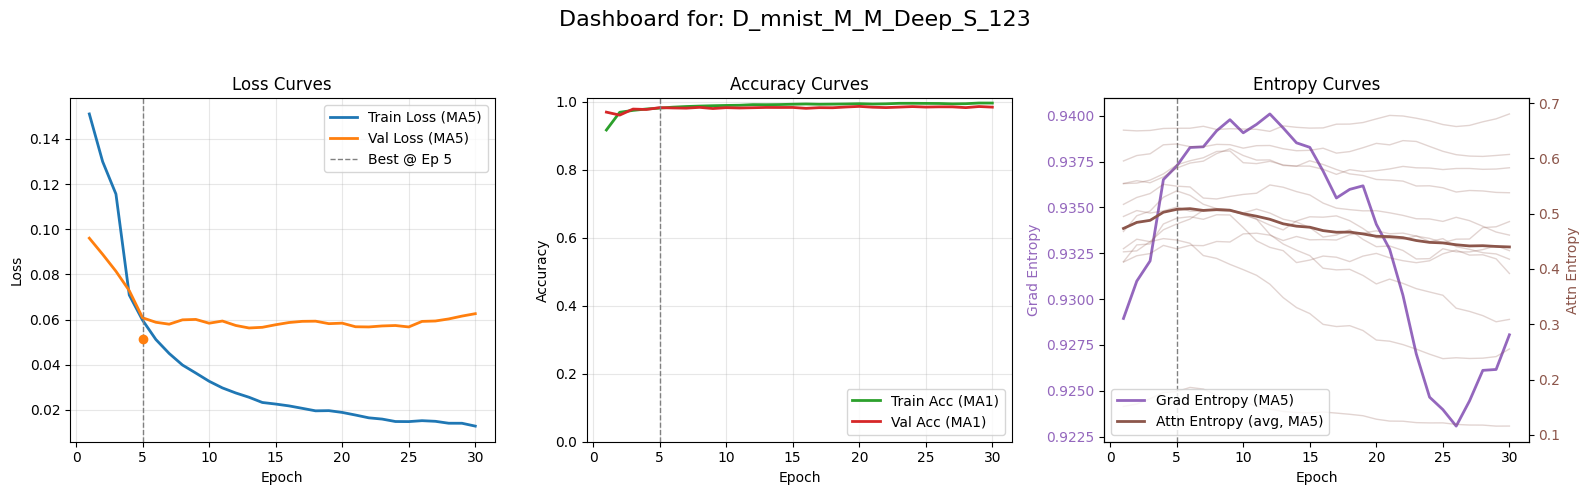

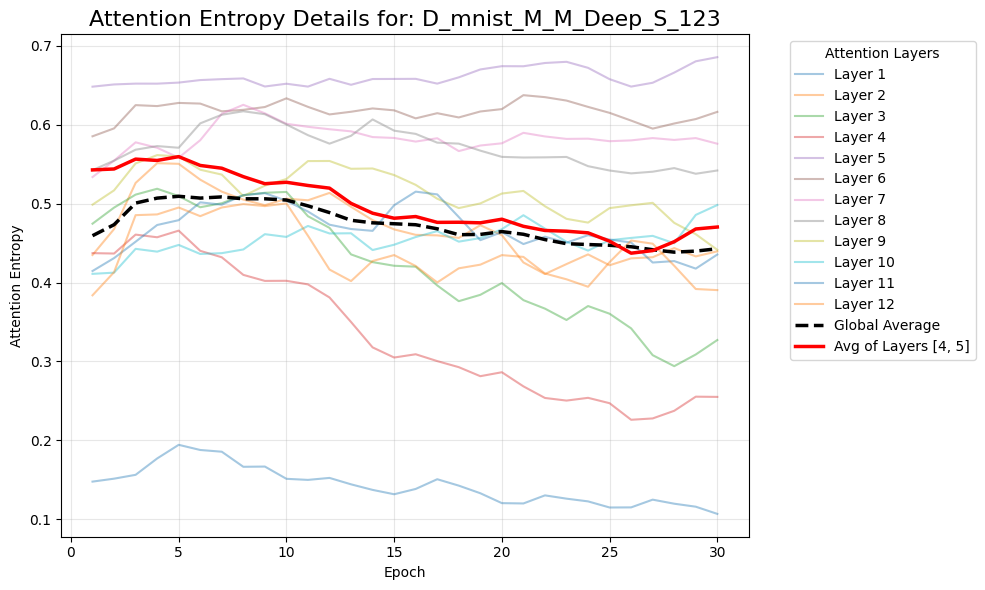

In [17]:
# ================== Plotting Driver ==================

### U-shaped global attention entropy
# --- 1. Experiment to visualize ---
DATASET = "mnist"      # 'mnist', 'cifar10', 'cifar100'
MODEL_TYPE = "M_Deep"     # 'M_Light', 'M_Base', 'M_Deep', 'M_Wide'
SEED = 123
OPTIMIZER = "Adam_noWD"   # 'Adam_noWD', 'Adam_WD',


# --- 2. Automatically load and parse log file ---

experiment_stem = ""
# Check if it's the original Adam experiment without an optimizer label
if OPTIMIZER == 'Adam_noWD':
    experiment_stem = f"D_{DATASET}_M_{MODEL_TYPE}_S_{SEED}"
else:
    # For all other optimizers, use the format with 'O' label
    experiment_stem = f"D_{DATASET}_M_{MODEL_TYPE}_O_{OPTIMIZER}_S_{SEED}"

filename = f"{experiment_stem}_logs.csv"
log_path = Path(OUTPUT_ROOT) / "grid_search" / filename

print(f"Loading log file: {log_path}")

try:
    df = pd.read_csv(log_path)
    print("✅ File loaded successfully, starting plot...")

    # Extract data series from DataFrame
    train_losses = df['train_loss'].values; val_losses = df['val_loss'].values
    train_accs = df['train_acc'].values; val_accs = df['val_acc'].values
    grad_entropies = df['grad_entropy'].values; attn_entropies_avg = df['attn_entropy_avg'].values
    attn_layer_cols = sorted([col for col in df.columns if 'attn_entropy_layer_' in col])
    attn_entropies_per_layer = [df[col].values for col in attn_layer_cols]

    # --- 3. Call plotting functions ---

    # Assume plot_three_panel_training and plot_attention_entropy_details functions are already defined in your environment

    plot_three_panel_training(
        train_losses=train_losses, val_losses=val_losses,
        train_accs=train_accs, val_accs=val_accs,
        grad_entropies=grad_entropies,
        attn_entropies_avg=attn_entropies_avg,
        attn_entropies_per_layer=attn_entropies_per_layer,
        smooth_windows={'loss': 5, 'acc': 1, 'entropy': 5},
        title=f"Dashboard for: {experiment_stem}"
    )

    plot_attention_entropy_details(
        attn_entropies_avg=attn_entropies_avg,
        attn_entropies_per_layer=attn_entropies_per_layer,
        smooth_window=3,
        avg_of_layers=(3, 4), # Example
        title=f"Attention Entropy Details for: {experiment_stem}"
    )

except FileNotFoundError:
    print(f"❌ Error: Log file not found! Please confirm the configuration above is correct.")
    print(f"   - The script is looking for this file: {log_path.name}")
except Exception as e:
    print(f"❌ An unknown error occurred: {e}")

Loading log file: /content/drive/MyDrive/Colab/VisionTransformer/outputs/grid_search/D_mnist_M_M_Base_O_Adam_WD_S_42_logs.csv
✅ File loaded successfully, starting plot...


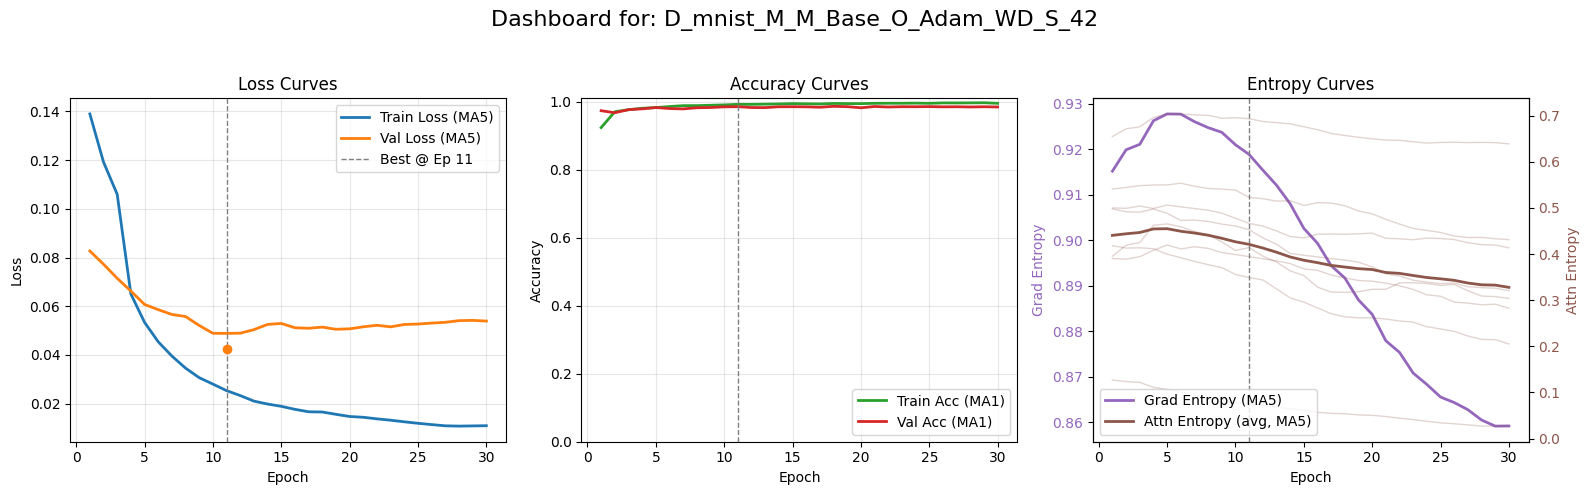

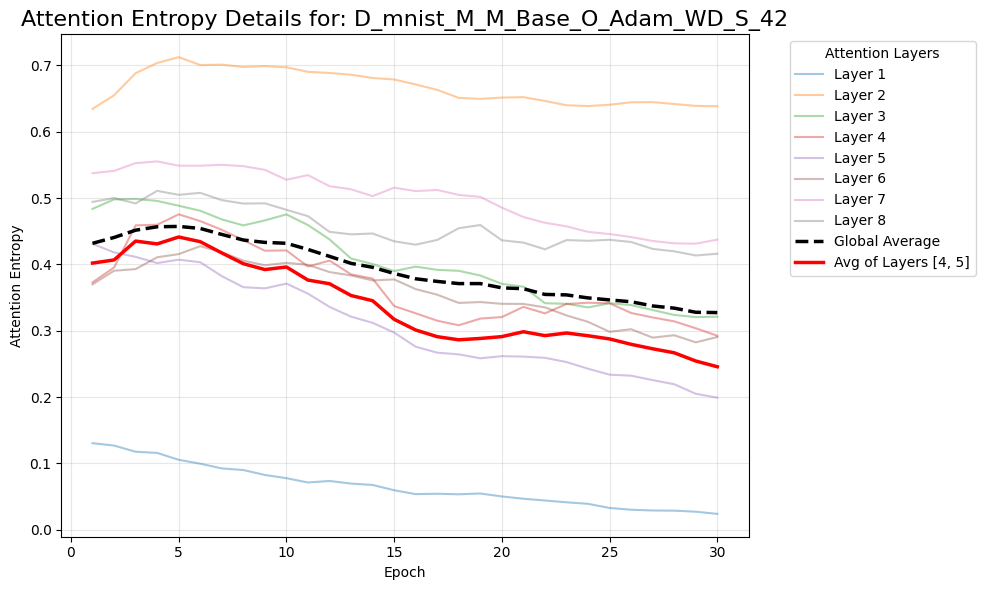

In [18]:
# ================== Plotting Driver ==================

### Impact of Weight Decay
# --- 1. Experiment to visualize ---
DATASET = "mnist"      # 'mnist', 'cifar10', 'cifar100'
MODEL_TYPE = "M_Base"     # 'M_Light', 'M_Base', 'M_Deep', 'M_Wide'
SEED = 42
OPTIMIZER = "Adam_WD"   # 'Adam_noWD', 'Adam_WD',


# --- 2. Automatically load and parse log file ---

experiment_stem = ""
# Check if it's the original Adam experiment without an optimizer label
if OPTIMIZER == 'Adam_noWD':
    experiment_stem = f"D_{DATASET}_M_{MODEL_TYPE}_S_{SEED}"
else:
    # For all other optimizers, use the format with 'O' label
    experiment_stem = f"D_{DATASET}_M_{MODEL_TYPE}_O_{OPTIMIZER}_S_{SEED}"

filename = f"{experiment_stem}_logs.csv"
log_path = Path(OUTPUT_ROOT) / "grid_search" / filename

print(f"Loading log file: {log_path}")

try:
    df = pd.read_csv(log_path)
    print("✅ File loaded successfully, starting plot...")

    # Extract data series from DataFrame
    train_losses = df['train_loss'].values; val_losses = df['val_loss'].values
    train_accs = df['train_acc'].values; val_accs = df['val_acc'].values
    grad_entropies = df['grad_entropy'].values; attn_entropies_avg = df['attn_entropy_avg'].values
    attn_layer_cols = sorted([col for col in df.columns if 'attn_entropy_layer_' in col])
    attn_entropies_per_layer = [df[col].values for col in attn_layer_cols]

    # --- 3. Call plotting functions ---

    # Assume plot_three_panel_training and plot_attention_entropy_details functions are already defined in your environment

    plot_three_panel_training(
        train_losses=train_losses, val_losses=val_losses,
        train_accs=train_accs, val_accs=val_accs,
        grad_entropies=grad_entropies,
        attn_entropies_avg=attn_entropies_avg,
        attn_entropies_per_layer=attn_entropies_per_layer,
        smooth_windows={'loss': 5, 'acc': 1, 'entropy': 5},
        title=f"Dashboard for: {experiment_stem}"
    )

    plot_attention_entropy_details(
        attn_entropies_avg=attn_entropies_avg,
        attn_entropies_per_layer=attn_entropies_per_layer,
        smooth_window=3,
        avg_of_layers=(3, 4), # Example
        title=f"Attention Entropy Details for: {experiment_stem}"
    )

except FileNotFoundError:
    print(f"❌ Error: Log file not found! Please confirm the configuration above is correct.")
    print(f"   - The script is looking for this file: {log_path.name}")
except Exception as e:
    print(f"❌ An unknown error occurred: {e}")

Loading log file: /content/drive/MyDrive/Colab/VisionTransformer/outputs/grid_search/D_cifar10_M_M_Light_S_42_logs.csv
✅ File loaded successfully, starting plot...


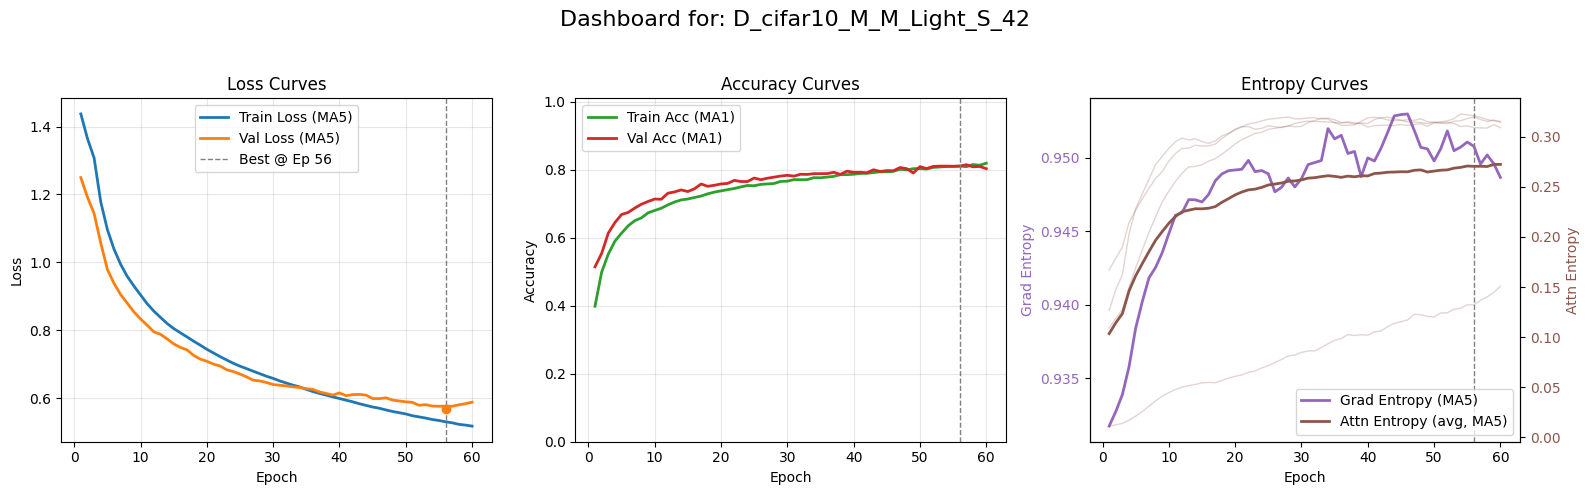

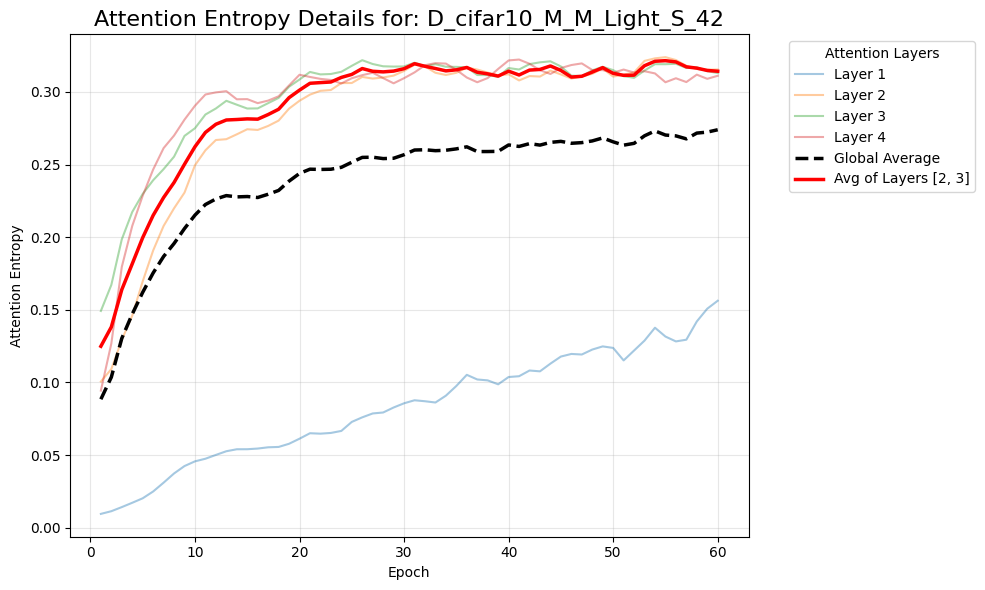

In [19]:
# ================== Plotting Driver ==================

# --- 1. Experiment to visualize ---
DATASET = "cifar10"      # 'mnist', 'cifar10', 'cifar100'
MODEL_TYPE = "M_Light"     # 'M_Light', 'M_Base', 'M_Deep', 'M_Wide'
SEED = 42
OPTIMIZER = "Adam_noWD"   # 'Adam_noWD', 'Adam_WD',


# --- 2. Automatically load and parse log file ---

experiment_stem = ""
# Check if it's the original Adam experiment without an optimizer label
if OPTIMIZER == 'Adam_noWD':
    experiment_stem = f"D_{DATASET}_M_{MODEL_TYPE}_S_{SEED}"
else:
    # For all other optimizers, use the format with 'O' label
    experiment_stem = f"D_{DATASET}_M_{MODEL_TYPE}_O_{OPTIMIZER}_S_{SEED}"

filename = f"{experiment_stem}_logs.csv"
log_path = Path(OUTPUT_ROOT) / "grid_search" / filename

print(f"Loading log file: {log_path}")

try:
    df = pd.read_csv(log_path)
    print("✅ File loaded successfully, starting plot...")

    # Extract data series from DataFrame
    train_losses = df['train_loss'].values; val_losses = df['val_loss'].values
    train_accs = df['train_acc'].values; val_accs = df['val_acc'].values
    grad_entropies = df['grad_entropy'].values; attn_entropies_avg = df['attn_entropy_avg'].values
    attn_layer_cols = sorted([col for col in df.columns if 'attn_entropy_layer_' in col])
    attn_entropies_per_layer = [df[col].values for col in attn_layer_cols]

    # --- 3. Call plotting functions ---

    # Assume plot_three_panel_training and plot_attention_entropy_details functions are already defined in your environment

    plot_three_panel_training(
        train_losses=train_losses, val_losses=val_losses,
        train_accs=train_accs, val_accs=val_accs,
        grad_entropies=grad_entropies,
        attn_entropies_avg=attn_entropies_avg,
        attn_entropies_per_layer=attn_entropies_per_layer,
        smooth_windows={'loss': 5, 'acc': 1, 'entropy': 5},
        title=f"Dashboard for: {experiment_stem}"
    )

    plot_attention_entropy_details(
        attn_entropies_avg=attn_entropies_avg,
        attn_entropies_per_layer=attn_entropies_per_layer,
        smooth_window=3,
        avg_of_layers=(1, 2), # Example
        title=f"Attention Entropy Details for: {experiment_stem}"
    )

except FileNotFoundError:
    print(f"❌ Error: Log file not found! Please confirm the configuration above is correct.")
    print(f"   - The script is looking for this file: {log_path.name}")
except Exception as e:
    print(f"❌ An unknown error occurred: {e}")

Loading log file: /content/drive/MyDrive/Colab/VisionTransformer/outputs/grid_search/D_cifar10_M_M_Light_O_Adam_WD_S_42_logs.csv
✅ File loaded successfully, starting plot...


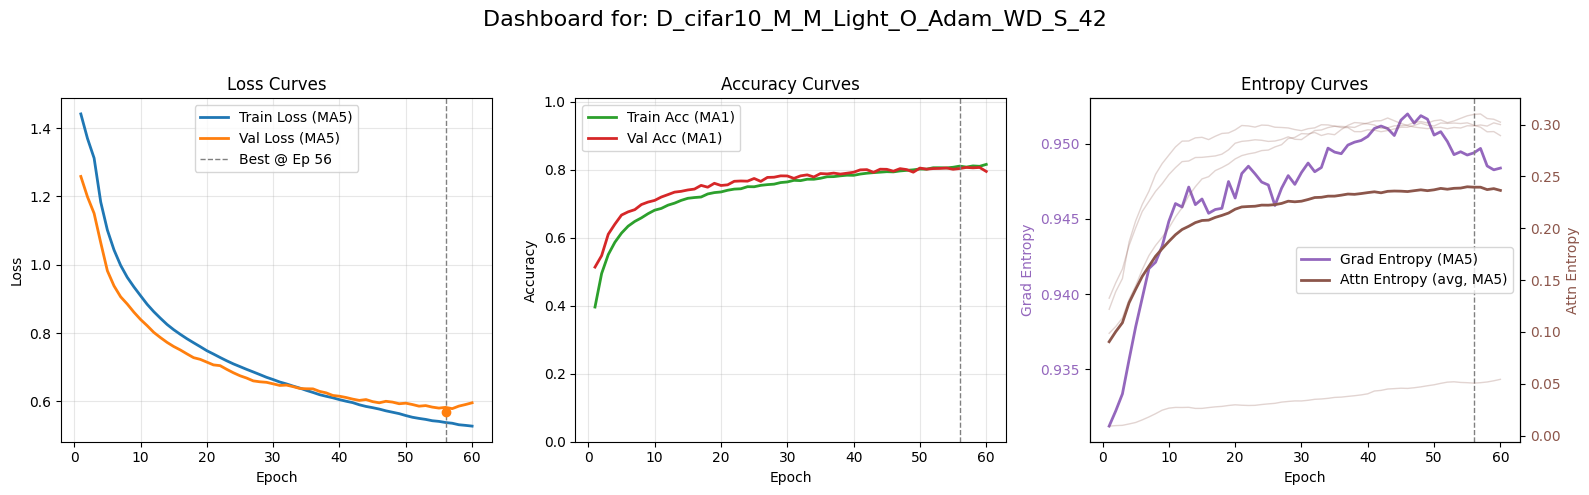

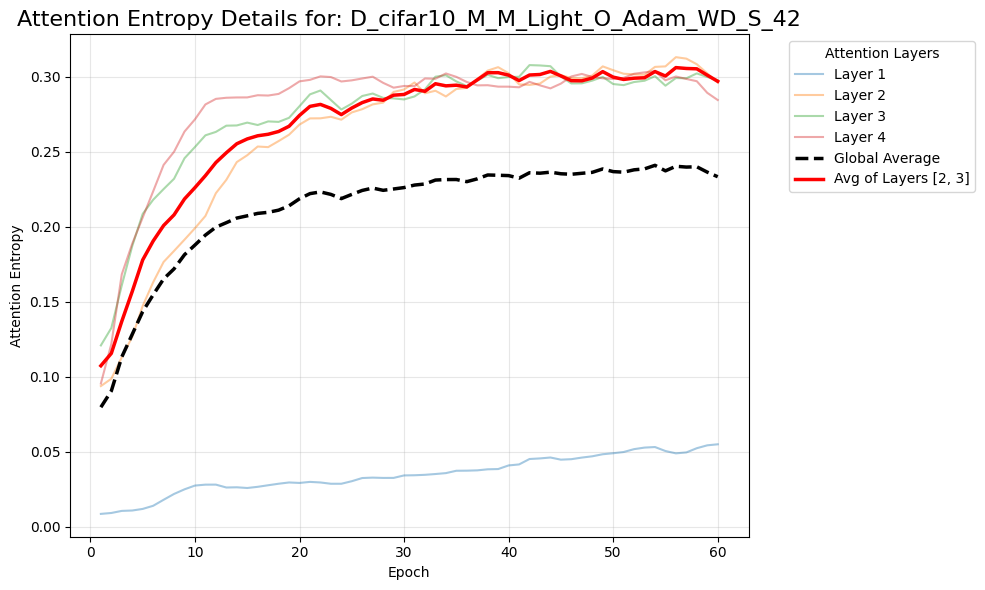

In [20]:
# ================== Plotting Driver ==================

# --- 1. Experiment to visualize ---
DATASET = "cifar10"      # 'mnist', 'cifar10', 'cifar100'
MODEL_TYPE = "M_Light"     # 'M_Light', 'M_Base', 'M_Deep', 'M_Wide'
SEED = 42
OPTIMIZER = "Adam_WD"   # 'Adam_noWD', 'Adam_WD',


# --- 2. Automatically load and parse log file ---

experiment_stem = ""
# Check if it's the original Adam experiment without an optimizer label
if OPTIMIZER == 'Adam_noWD':
    experiment_stem = f"D_{DATASET}_M_{MODEL_TYPE}_S_{SEED}"
else:
    # For all other optimizers, use the format with 'O' label
    experiment_stem = f"D_{DATASET}_M_{MODEL_TYPE}_O_{OPTIMIZER}_S_{SEED}"

filename = f"{experiment_stem}_logs.csv"
log_path = Path(OUTPUT_ROOT) / "grid_search" / filename

print(f"Loading log file: {log_path}")

try:
    df = pd.read_csv(log_path)
    print("✅ File loaded successfully, starting plot...")

    # Extract data series from DataFrame
    train_losses = df['train_loss'].values; val_losses = df['val_loss'].values
    train_accs = df['train_acc'].values; val_accs = df['val_acc'].values
    grad_entropies = df['grad_entropy'].values; attn_entropies_avg = df['attn_entropy_avg'].values
    attn_layer_cols = sorted([col for col in df.columns if 'attn_entropy_layer_' in col])
    attn_entropies_per_layer = [df[col].values for col in attn_layer_cols]

    # --- 3. Call plotting functions ---

    # Assume plot_three_panel_training and plot_attention_entropy_details functions are already defined in your environment

    plot_three_panel_training(
        train_losses=train_losses, val_losses=val_losses,
        train_accs=train_accs, val_accs=val_accs,
        grad_entropies=grad_entropies,
        attn_entropies_avg=attn_entropies_avg,
        attn_entropies_per_layer=attn_entropies_per_layer,
        smooth_windows={'loss': 5, 'acc': 1, 'entropy': 5},
        title=f"Dashboard for: {experiment_stem}"
    )

    plot_attention_entropy_details(
        attn_entropies_avg=attn_entropies_avg,
        attn_entropies_per_layer=attn_entropies_per_layer,
        smooth_window=3,
        avg_of_layers=(1, 2), # Example
        title=f"Attention Entropy Details for: {experiment_stem}"
    )

except FileNotFoundError:
    print(f"❌ Error: Log file not found! Please confirm the configuration above is correct.")
    print(f"   - The script is looking for this file: {log_path.name}")
except Exception as e:
    print(f"❌ An unknown error occurred: {e}")

Loading log file: /content/drive/MyDrive/Colab/VisionTransformer/outputs/grid_search/D_cifar10_M_M_Base_S_42_logs.csv
✅ File loaded successfully, starting plot...


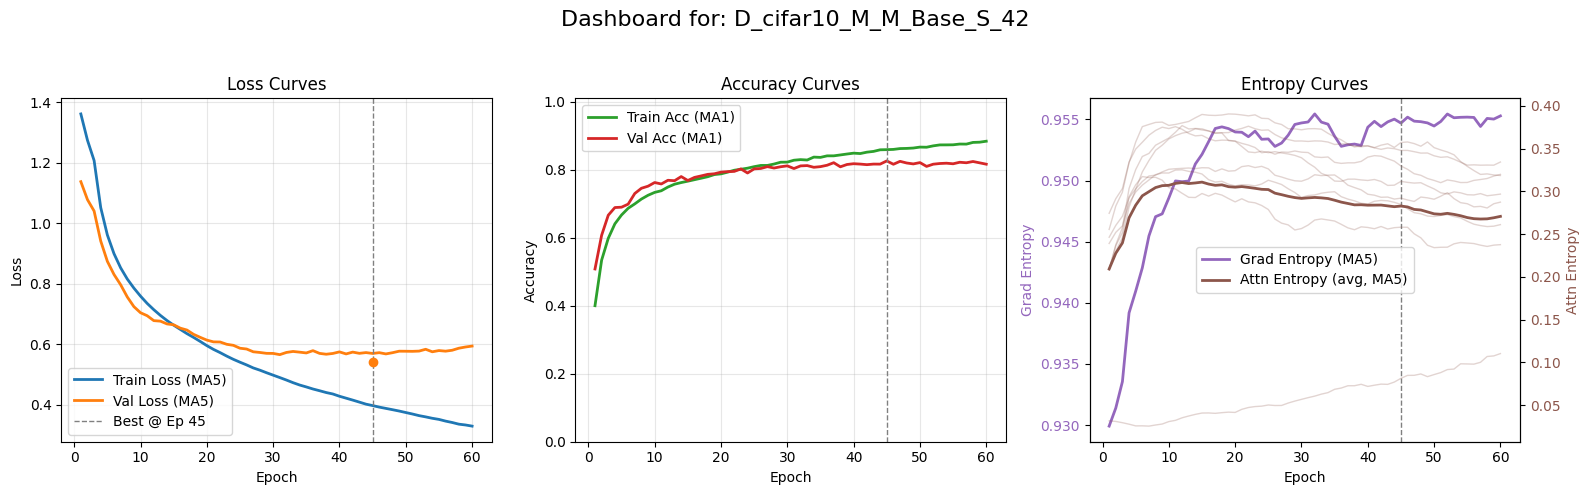

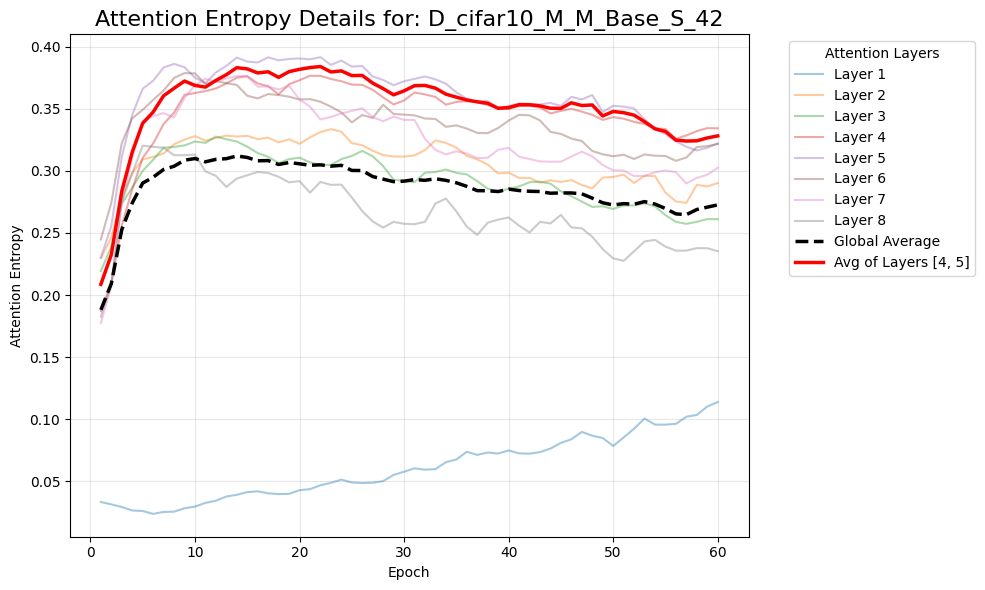

In [21]:
# ================== Plotting Driver ==================

# --- 1. Experiment to visualize ---
DATASET = "cifar10"      # 'mnist', 'cifar10', 'cifar100'
MODEL_TYPE = "M_Base"     # 'M_Light', 'M_Base', 'M_Deep', 'M_Wide'
SEED = 42
OPTIMIZER = "Adam_noWD"   # 'Adam_noWD', 'Adam_WD',


# --- 2. Automatically load and parse log file ---

experiment_stem = ""
# Check if it's the original Adam experiment without an optimizer label
if OPTIMIZER == 'Adam_noWD':
    experiment_stem = f"D_{DATASET}_M_{MODEL_TYPE}_S_{SEED}"
else:
    # For all other optimizers, use the format with 'O' label
    experiment_stem = f"D_{DATASET}_M_{MODEL_TYPE}_O_{OPTIMIZER}_S_{SEED}"

filename = f"{experiment_stem}_logs.csv"
log_path = Path(OUTPUT_ROOT) / "grid_search" / filename

print(f"Loading log file: {log_path}")

try:
    df = pd.read_csv(log_path)
    print("✅ File loaded successfully, starting plot...")

    # Extract data series from DataFrame
    train_losses = df['train_loss'].values; val_losses = df['val_loss'].values
    train_accs = df['train_acc'].values; val_accs = df['val_acc'].values
    grad_entropies = df['grad_entropy'].values; attn_entropies_avg = df['attn_entropy_avg'].values
    attn_layer_cols = sorted([col for col in df.columns if 'attn_entropy_layer_' in col])
    attn_entropies_per_layer = [df[col].values for col in attn_layer_cols]

    # --- 3. Call plotting functions ---

    # Assume plot_three_panel_training and plot_attention_entropy_details functions are already defined in your environment

    plot_three_panel_training(
        train_losses=train_losses, val_losses=val_losses,
        train_accs=train_accs, val_accs=val_accs,
        grad_entropies=grad_entropies,
        attn_entropies_avg=attn_entropies_avg,
        attn_entropies_per_layer=attn_entropies_per_layer,
        smooth_windows={'loss': 5, 'acc': 1, 'entropy': 5},
        title=f"Dashboard for: {experiment_stem}"
    )

    plot_attention_entropy_details(
        attn_entropies_avg=attn_entropies_avg,
        attn_entropies_per_layer=attn_entropies_per_layer,
        smooth_window=3,
        avg_of_layers=(3, 4), # Example
        title=f"Attention Entropy Details for: {experiment_stem}"
    )

except FileNotFoundError:
    print(f"❌ Error: Log file not found! Please confirm the configuration above is correct.")
    print(f"   - The script is looking for this file: {log_path.name}")
except Exception as e:
    print(f"❌ An unknown error occurred: {e}")

Loading log file: /content/drive/MyDrive/Colab/VisionTransformer/outputs/grid_search/D_cifar10_M_M_Base_O_Adam_WD_S_42_logs.csv
✅ File loaded successfully, starting plot...


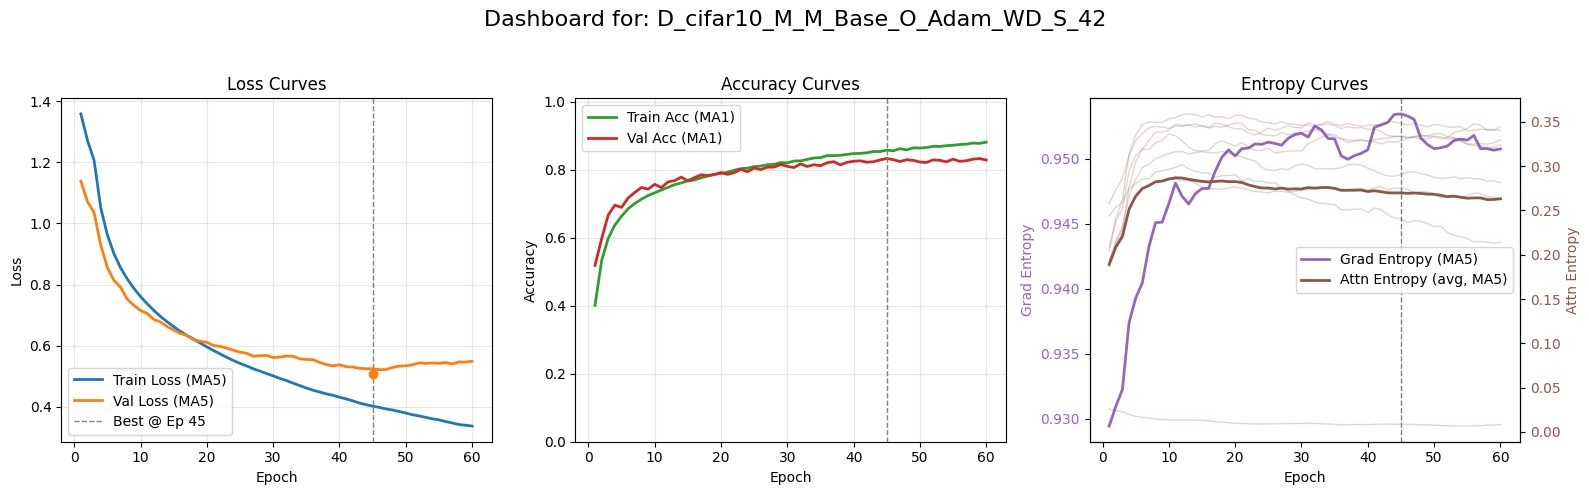

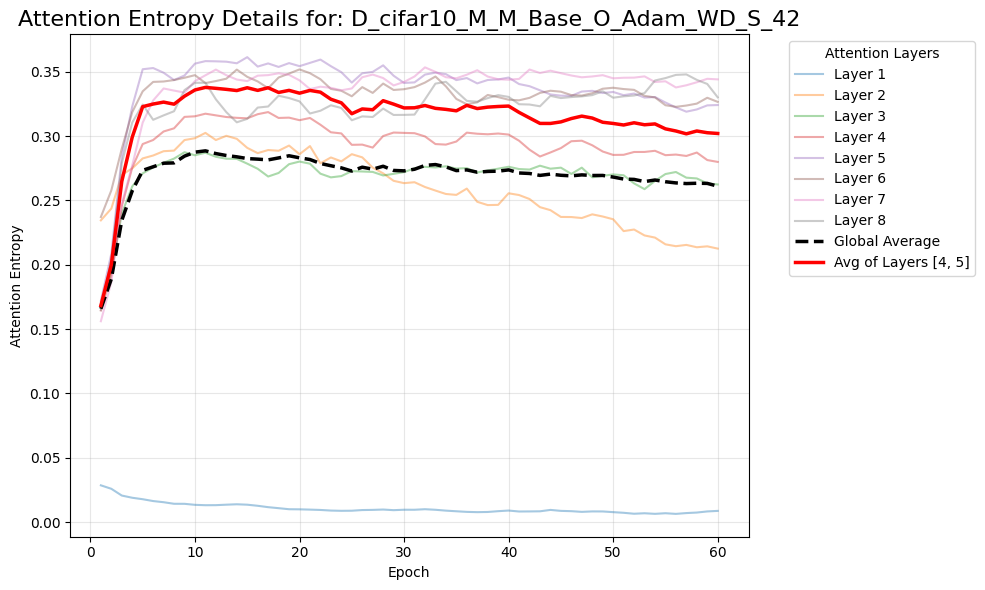

In [22]:
# ================== Plotting Driver ==================

# --- 1. Experiment to visualize ---
DATASET = "cifar10"      # 'mnist', 'cifar10', 'cifar100'
MODEL_TYPE = "M_Base"     # 'M_Light', 'M_Base', 'M_Deep', 'M_Wide'
SEED = 42
OPTIMIZER = "Adam_WD"   # 'Adam_noWD', 'Adam_WD',


# --- 2. Automatically load and parse log file ---

experiment_stem = ""
# Check if it's the original Adam experiment without an optimizer label
if OPTIMIZER == 'Adam_noWD':
    experiment_stem = f"D_{DATASET}_M_{MODEL_TYPE}_S_{SEED}"
else:
    # For all other optimizers, use the format with 'O' label
    experiment_stem = f"D_{DATASET}_M_{MODEL_TYPE}_O_{OPTIMIZER}_S_{SEED}"

filename = f"{experiment_stem}_logs.csv"
log_path = Path(OUTPUT_ROOT) / "grid_search" / filename

print(f"Loading log file: {log_path}")

try:
    df = pd.read_csv(log_path)
    print("✅ File loaded successfully, starting plot...")

    # Extract data series from DataFrame
    train_losses = df['train_loss'].values; val_losses = df['val_loss'].values
    train_accs = df['train_acc'].values; val_accs = df['val_acc'].values
    grad_entropies = df['grad_entropy'].values; attn_entropies_avg = df['attn_entropy_avg'].values
    attn_layer_cols = sorted([col for col in df.columns if 'attn_entropy_layer_' in col])
    attn_entropies_per_layer = [df[col].values for col in attn_layer_cols]

    # --- 3. Call plotting functions ---

    # Assume plot_three_panel_training and plot_attention_entropy_details functions are already defined in your environment

    plot_three_panel_training(
        train_losses=train_losses, val_losses=val_losses,
        train_accs=train_accs, val_accs=val_accs,
        grad_entropies=grad_entropies,
        attn_entropies_avg=attn_entropies_avg,
        attn_entropies_per_layer=attn_entropies_per_layer,
        smooth_windows={'loss': 5, 'acc': 1, 'entropy': 5},
        title=f"Dashboard for: {experiment_stem}"
    )

    plot_attention_entropy_details(
        attn_entropies_avg=attn_entropies_avg,
        attn_entropies_per_layer=attn_entropies_per_layer,
        smooth_window=3,
        avg_of_layers=(3, 4), # Example
        title=f"Attention Entropy Details for: {experiment_stem}"
    )


except FileNotFoundError:
    print(f"❌ Error: Log file not found! Please confirm the configuration above is correct.")
    print(f"   - The script is looking for this file: {log_path.name}")
except Exception as e:
    print(f"❌ An unknown error occurred: {e}")

Loading log file: /content/drive/MyDrive/Colab/VisionTransformer/outputs/grid_search/D_cifar10_M_M_Deep_S_42_logs.csv
✅ File loaded successfully, starting plot...


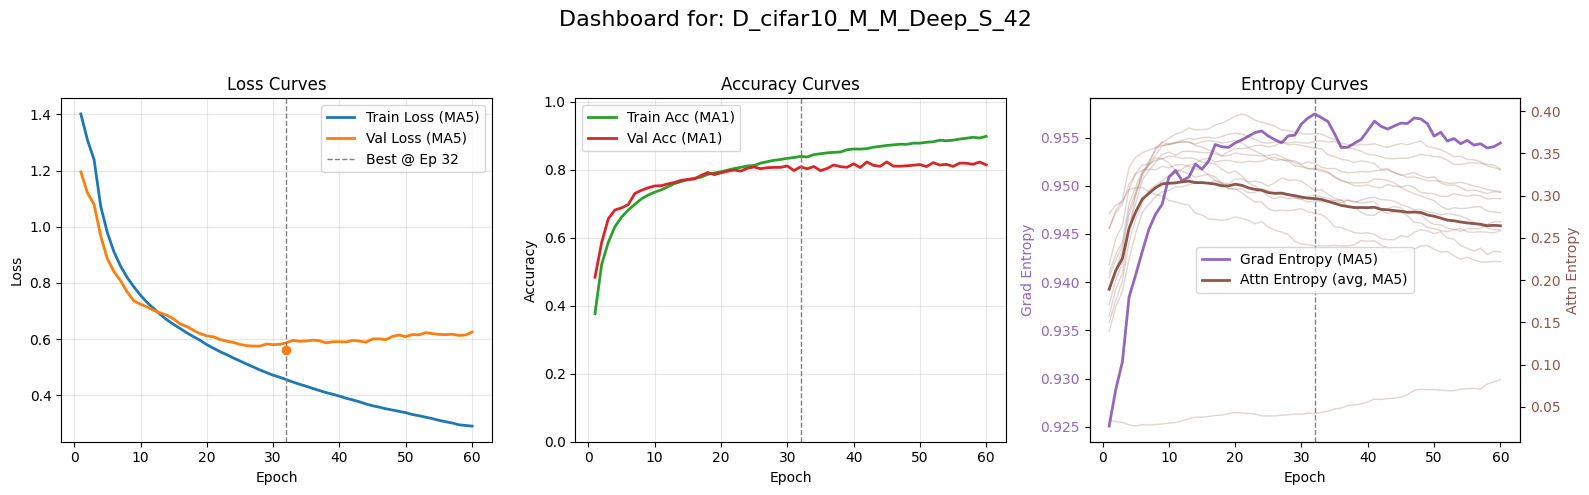

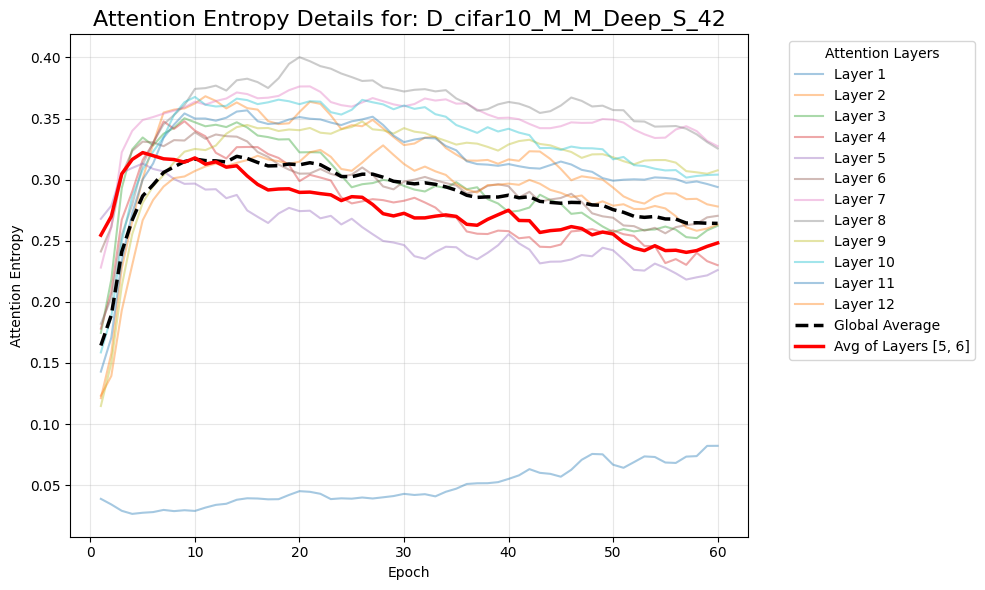

In [23]:
# ================== Plotting Driver ==================

# --- 1. Experiment to visualize ---
DATASET = "cifar10"      # 'mnist', 'cifar10', 'cifar100'
MODEL_TYPE = "M_Deep"     # 'M_Light', 'M_Base', 'M_Deep', 'M_Wide'
SEED = 42
OPTIMIZER = "Adam_noWD"   # 'Adam_noWD', 'Adam_WD',


# --- 2. Automatically load and parse log file ---

experiment_stem = ""
# Check if it's the original Adam experiment without an optimizer label
if OPTIMIZER == 'Adam_noWD':
    experiment_stem = f"D_{DATASET}_M_{MODEL_TYPE}_S_{SEED}"
else:
    # For all other optimizers, use the format with 'O' label
    experiment_stem = f"D_{DATASET}_M_{MODEL_TYPE}_O_{OPTIMIZER}_S_{SEED}"

filename = f"{experiment_stem}_logs.csv"
log_path = Path(OUTPUT_ROOT) / "grid_search" / filename

print(f"Loading log file: {log_path}")

try:
    df = pd.read_csv(log_path)
    print("✅ File loaded successfully, starting plot...")

    # Extract data series from DataFrame
    train_losses = df['train_loss'].values; val_losses = df['val_loss'].values
    train_accs = df['train_acc'].values; val_accs = df['val_acc'].values
    grad_entropies = df['grad_entropy'].values; attn_entropies_avg = df['attn_entropy_avg'].values
    attn_layer_cols = sorted([col for col in df.columns if 'attn_entropy_layer_' in col])
    attn_entropies_per_layer = [df[col].values for col in attn_layer_cols]

    # --- 3. Call plotting functions ---

    # Assume plot_three_panel_training and plot_attention_entropy_details functions are already defined in your environment

    plot_three_panel_training(
        train_losses=train_losses, val_losses=val_losses,
        train_accs=train_accs, val_accs=val_accs,
        grad_entropies=grad_entropies,
        attn_entropies_avg=attn_entropies_avg,
        attn_entropies_per_layer=attn_entropies_per_layer,
        smooth_windows={'loss': 5, 'acc': 1, 'entropy': 5},
        title=f"Dashboard for: {experiment_stem}"
    )

    plot_attention_entropy_details(
        attn_entropies_avg=attn_entropies_avg,
        attn_entropies_per_layer=attn_entropies_per_layer,
        smooth_window=3,
        avg_of_layers=(4, 5), # Example
        title=f"Attention Entropy Details for: {experiment_stem}"
    )


except FileNotFoundError:
    print(f"❌ Error: Log file not found! Please confirm the configuration above is correct.")
    print(f"   - The script is looking for this file: {log_path.name}")
except Exception as e:
    print(f"❌ An unknown error occurred: {e}")

Loading log file: /content/drive/MyDrive/Colab/VisionTransformer/outputs/grid_search/D_cifar10_M_M_Deep_O_Adam_WD_S_42_logs.csv
✅ File loaded successfully, starting plot...


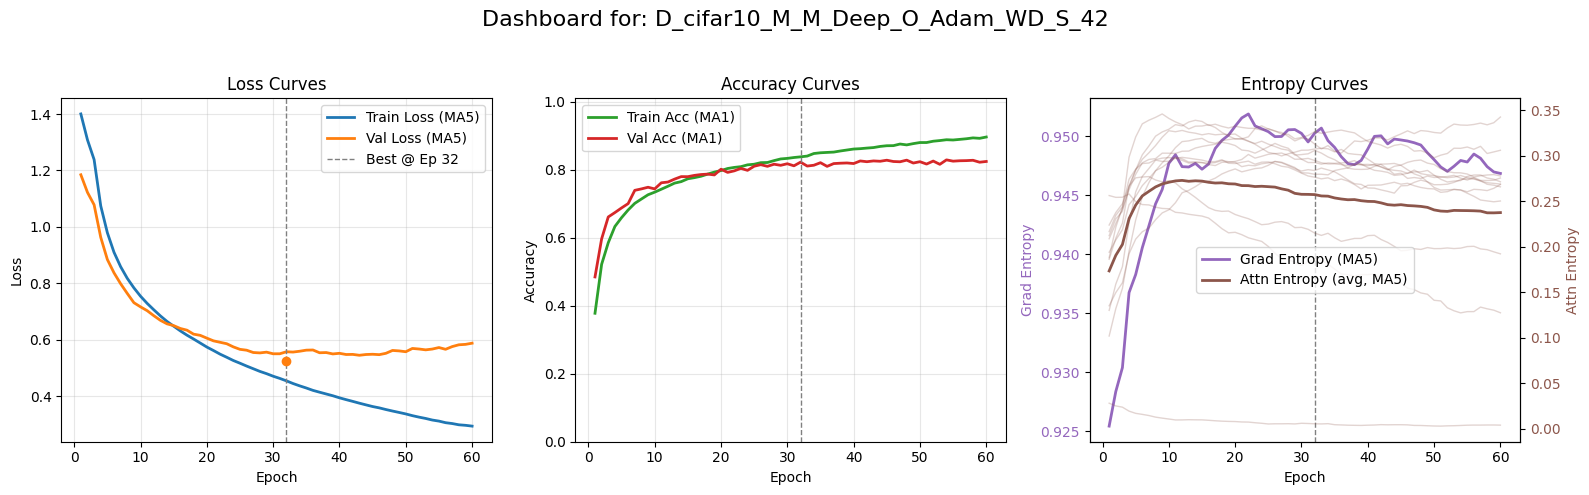

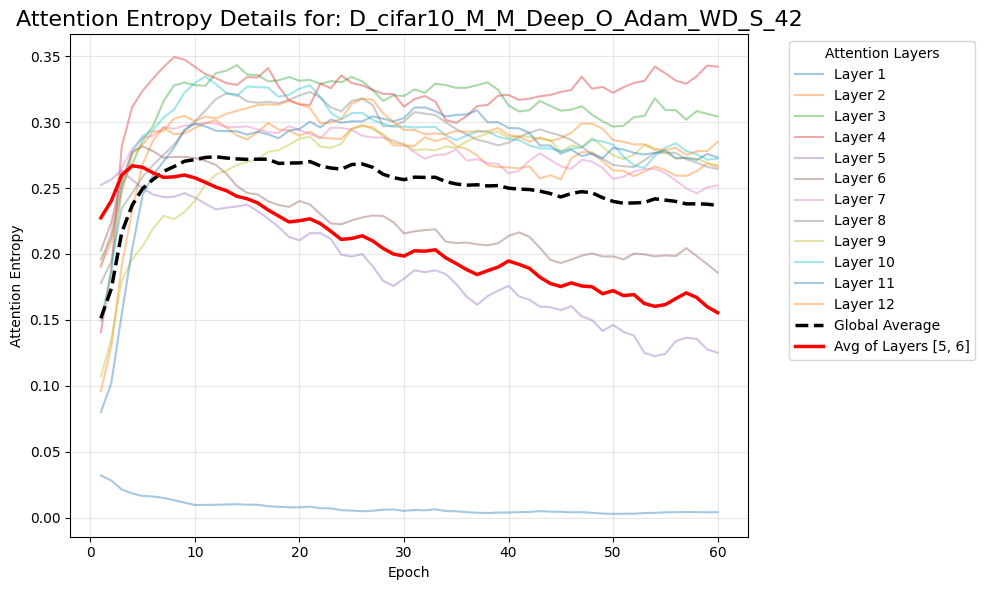

In [24]:
# ================== Plotting Driver ==================

# --- 1. Experiment to visualize ---
DATASET = "cifar10"      # 'mnist', 'cifar10', 'cifar100'
MODEL_TYPE = "M_Deep"     # 'M_Light', 'M_Base', 'M_Deep', 'M_Wide'
SEED = 42
OPTIMIZER = "Adam_WD"   # 'Adam_noWD', 'Adam_WD',


# --- 2. Automatically load and parse log file ---

experiment_stem = ""
# Check if it's the original Adam experiment without an optimizer label
if OPTIMIZER == 'Adam_noWD':
    experiment_stem = f"D_{DATASET}_M_{MODEL_TYPE}_S_{SEED}"
else:
    # For all other optimizers, use the format with 'O' label
    experiment_stem = f"D_{DATASET}_M_{MODEL_TYPE}_O_{OPTIMIZER}_S_{SEED}"

filename = f"{experiment_stem}_logs.csv"
log_path = Path(OUTPUT_ROOT) / "grid_search" / filename

print(f"Loading log file: {log_path}")

try:
    df = pd.read_csv(log_path)
    print("✅ File loaded successfully, starting plot...")

    # Extract data series from DataFrame
    train_losses = df['train_loss'].values; val_losses = df['val_loss'].values
    train_accs = df['train_acc'].values; val_accs = df['val_acc'].values
    grad_entropies = df['grad_entropy'].values; attn_entropies_avg = df['attn_entropy_avg'].values
    attn_layer_cols = sorted([col for col in df.columns if 'attn_entropy_layer_' in col])
    attn_entropies_per_layer = [df[col].values for col in attn_layer_cols]

    # --- 3. Call plotting functions ---

    # Assume plot_three_panel_training and plot_attention_entropy_details functions are already defined in your environment

    plot_three_panel_training(
        train_losses=train_losses, val_losses=val_losses,
        train_accs=train_accs, val_accs=val_accs,
        grad_entropies=grad_entropies,
        attn_entropies_avg=attn_entropies_avg,
        attn_entropies_per_layer=attn_entropies_per_layer,
        smooth_windows={'loss': 5, 'acc': 1, 'entropy': 5},
        title=f"Dashboard for: {experiment_stem}"
    )

    plot_attention_entropy_details(
        attn_entropies_avg=attn_entropies_avg,
        attn_entropies_per_layer=attn_entropies_per_layer,
        smooth_window=3,
        avg_of_layers=(4, 5), # Example
        title=f"Attention Entropy Details for: {experiment_stem}"
    )


except FileNotFoundError:
    print(f"❌ Error: Log file not found! Please confirm the configuration above is correct.")
    print(f"   - The script is looking for this file: {log_path.name}")
except Exception as e:
    print(f"❌ An unknown error occurred: {e}")

Loading log file: /content/drive/MyDrive/Colab/VisionTransformer/outputs/grid_search/D_cifar10_M_M_Wide_S_42_logs.csv
✅ File loaded successfully, starting plot...


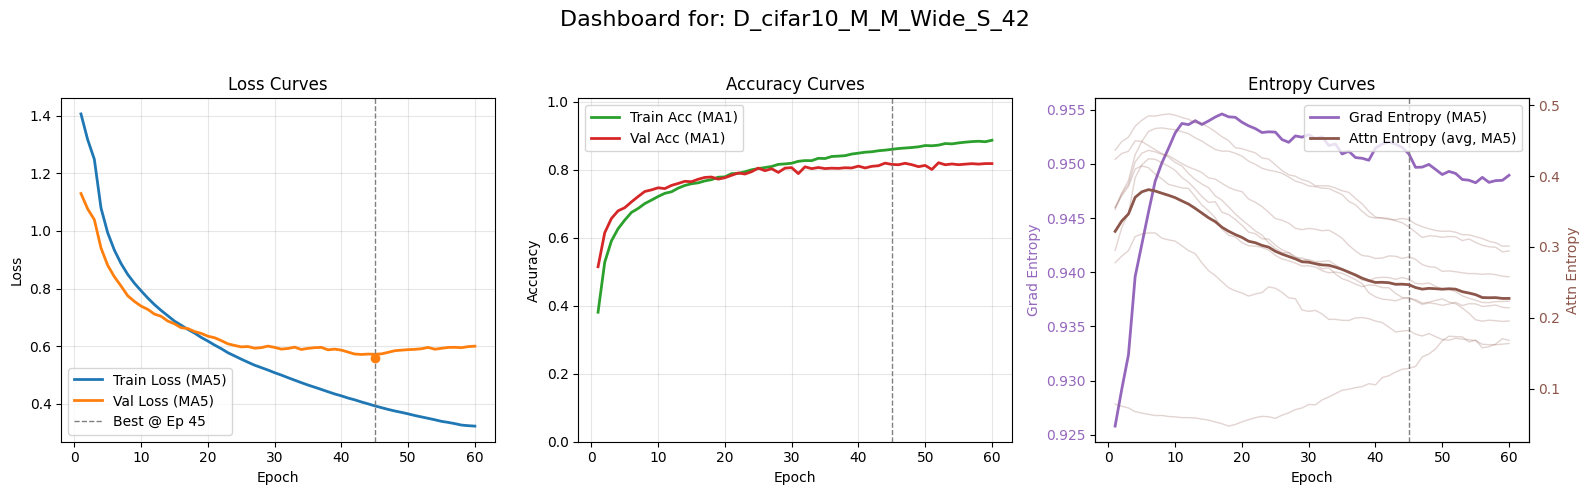

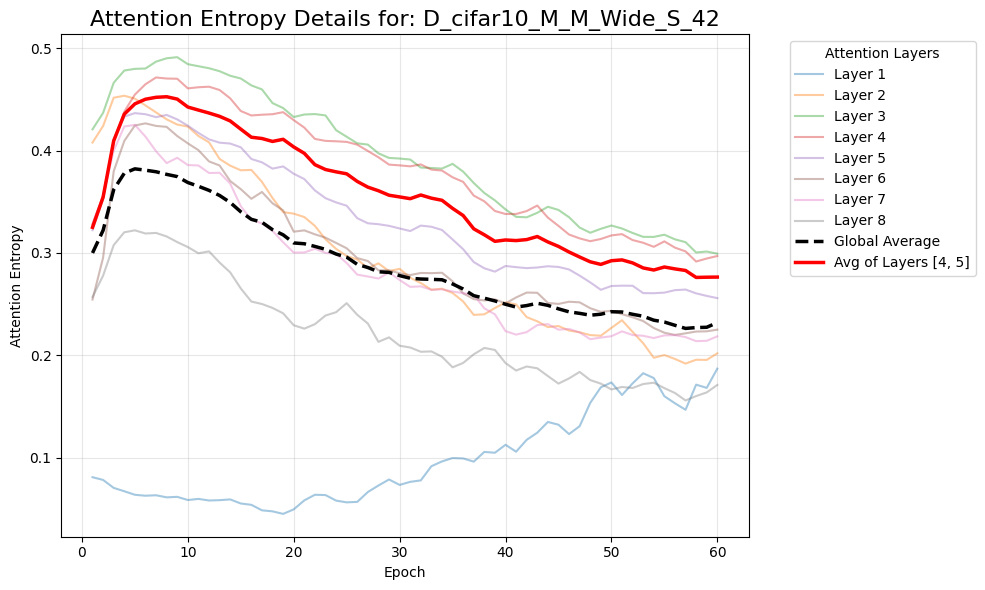

In [25]:
# ================== Plotting Driver ==================

# --- 1. Experiment to visualize ---
DATASET = "cifar10"      # 'mnist', 'cifar10', 'cifar100'
MODEL_TYPE = "M_Wide"     # 'M_Light', 'M_Base', 'M_Deep', 'M_Wide'
SEED = 42
OPTIMIZER = "Adam_noWD"   # 'Adam_noWD', 'Adam_WD',


# --- 2. Automatically load and parse log file ---

experiment_stem = ""
# Check if it's the original Adam experiment without an optimizer label
if OPTIMIZER == 'Adam_noWD':
    experiment_stem = f"D_{DATASET}_M_{MODEL_TYPE}_S_{SEED}"
else:
    # For all other optimizers, use the format with 'O' label
    experiment_stem = f"D_{DATASET}_M_{MODEL_TYPE}_O_{OPTIMIZER}_S_{SEED}"

filename = f"{experiment_stem}_logs.csv"
log_path = Path(OUTPUT_ROOT) / "grid_search" / filename

print(f"Loading log file: {log_path}")

try:
    df = pd.read_csv(log_path)
    print("✅ File loaded successfully, starting plot...")

    # Extract data series from DataFrame
    train_losses = df['train_loss'].values; val_losses = df['val_loss'].values
    train_accs = df['train_acc'].values; val_accs = df['val_acc'].values
    grad_entropies = df['grad_entropy'].values; attn_entropies_avg = df['attn_entropy_avg'].values
    attn_layer_cols = sorted([col for col in df.columns if 'attn_entropy_layer_' in col])
    attn_entropies_per_layer = [df[col].values for col in attn_layer_cols]

    # --- 3. Call plotting functions ---

    # Assume plot_three_panel_training and plot_attention_entropy_details functions are already defined in your environment

    plot_three_panel_training(
        train_losses=train_losses, val_losses=val_losses,
        train_accs=train_accs, val_accs=val_accs,
        grad_entropies=grad_entropies,
        attn_entropies_avg=attn_entropies_avg,
        attn_entropies_per_layer=attn_entropies_per_layer,
        smooth_windows={'loss': 5, 'acc': 1, 'entropy': 5},
        title=f"Dashboard for: {experiment_stem}"
    )

    plot_attention_entropy_details(
        attn_entropies_avg=attn_entropies_avg,
        attn_entropies_per_layer=attn_entropies_per_layer,
        smooth_window=3,
        avg_of_layers=(3, 4), # Example
        title=f"Attention Entropy Details for: {experiment_stem}"
    )


except FileNotFoundError:
    print(f"❌ Error: Log file not found! Please confirm the configuration above is correct.")
    print(f"   - The script is looking for this file: {log_path.name}")
except Exception as e:
    print(f"❌ An unknown error occurred: {e}")

In [26]:
    train_losses = df['train_loss'].values; val_losses = df['val_loss'].values


Loading log file: /content/drive/MyDrive/Colab/VisionTransformer/outputs/grid_search/D_cifar10_M_M_Wide_O_Adam_WD_S_42_logs.csv
✅ File loaded successfully, starting plot...


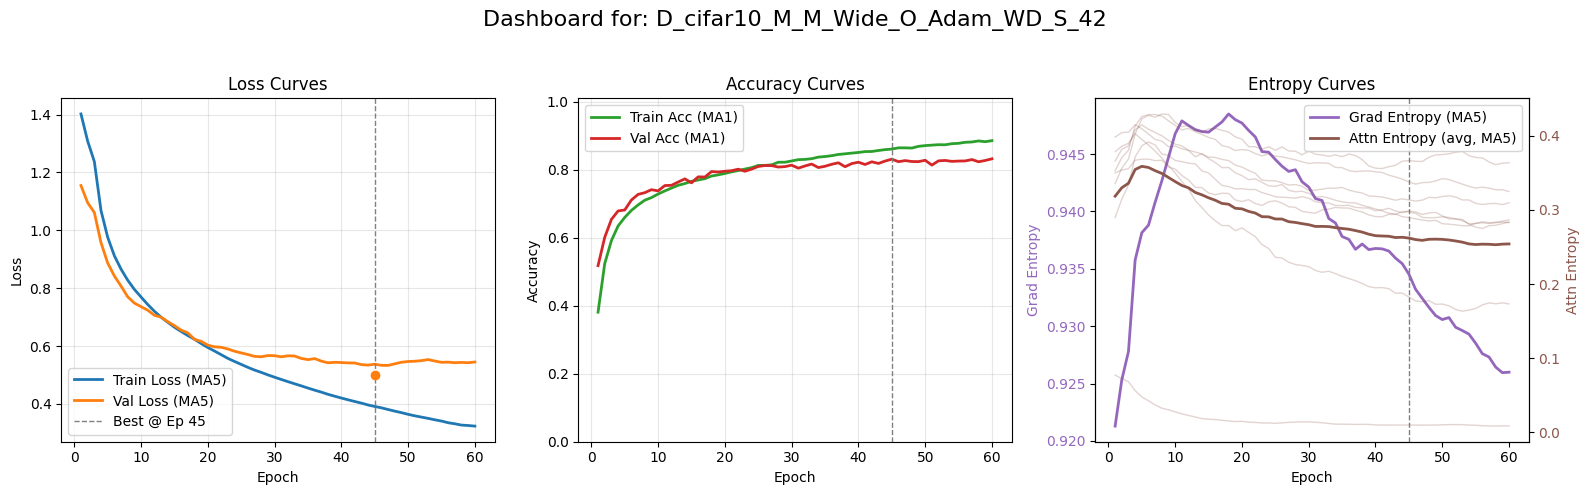

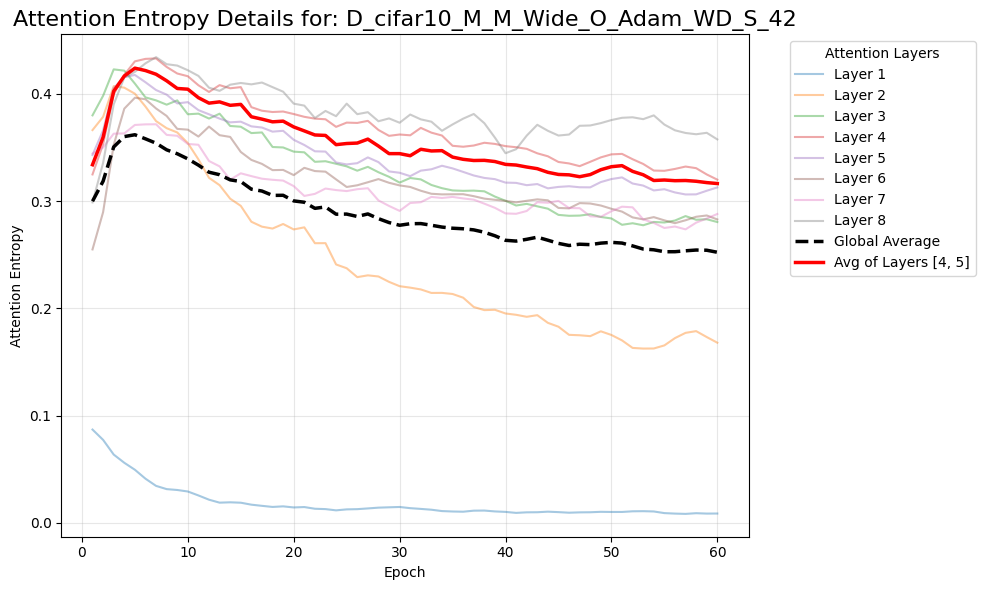

In [27]:
# ================== Plotting Driver ==================

# --- 1. Experiment to visualize ---
DATASET = "cifar10"      # 'mnist', 'cifar10', 'cifar100'
MODEL_TYPE = "M_Wide"     # 'M_Light', 'M_Base', 'M_Deep', 'M_Wide'
SEED = 42
OPTIMIZER = "Adam_WD"   # 'Adam_noWD', 'Adam_WD',


# --- 2. Automatically load and parse log file ---

experiment_stem = ""
# Check if it's the original Adam experiment without an optimizer label
if OPTIMIZER == 'Adam_noWD':
    experiment_stem = f"D_{DATASET}_M_{MODEL_TYPE}_S_{SEED}"
else:
    # For all other optimizers, use the format with 'O' label
    experiment_stem = f"D_{DATASET}_M_{MODEL_TYPE}_O_{OPTIMIZER}_S_{SEED}"

filename = f"{experiment_stem}_logs.csv"
log_path = Path(OUTPUT_ROOT) / "grid_search" / filename

print(f"Loading log file: {log_path}")

try:
    df = pd.read_csv(log_path)
    print("✅ File loaded successfully, starting plot...")

    # Extract data series from DataFrame
    train_losses = df['train_loss'].values; val_losses = df['val_loss'].values
    train_accs = df['train_acc'].values; val_accs = df['val_acc'].values
    grad_entropies = df['grad_entropy'].values; attn_entropies_avg = df['attn_entropy_avg'].values
    attn_layer_cols = sorted([col for col in df.columns if 'attn_entropy_layer_' in col])
    attn_entropies_per_layer = [df[col].values for col in attn_layer_cols]

    # --- 3. Call plotting functions ---

    # Assume plot_three_panel_training and plot_attention_entropy_details functions are already defined in your environment

    plot_three_panel_training(
        train_losses=train_losses, val_losses=val_losses,
        train_accs=train_accs, val_accs=val_accs,
        grad_entropies=grad_entropies,
        attn_entropies_avg=attn_entropies_avg,
        attn_entropies_per_layer=attn_entropies_per_layer,
        smooth_windows={'loss': 5, 'acc': 1, 'entropy': 5},
        title=f"Dashboard for: {experiment_stem}"
    )

    plot_attention_entropy_details(
        attn_entropies_avg=attn_entropies_avg,
        attn_entropies_per_layer=attn_entropies_per_layer,
        smooth_window=3,
        avg_of_layers=(3, 4), # Example
        title=f"Attention Entropy Details for: {experiment_stem}"
    )


except FileNotFoundError:
    print(f"❌ Error: Log file not found! Please confirm the configuration above is correct.")
    print(f"   - The script is looking for this file: {log_path.name}")
except Exception as e:
    print(f"❌ An unknown error occurred: {e}")

Loading log file: /content/drive/MyDrive/Colab/VisionTransformer/outputs/grid_search/D_cifar100_M_M_Light_S_42_logs.csv
✅ File loaded successfully, starting plot...


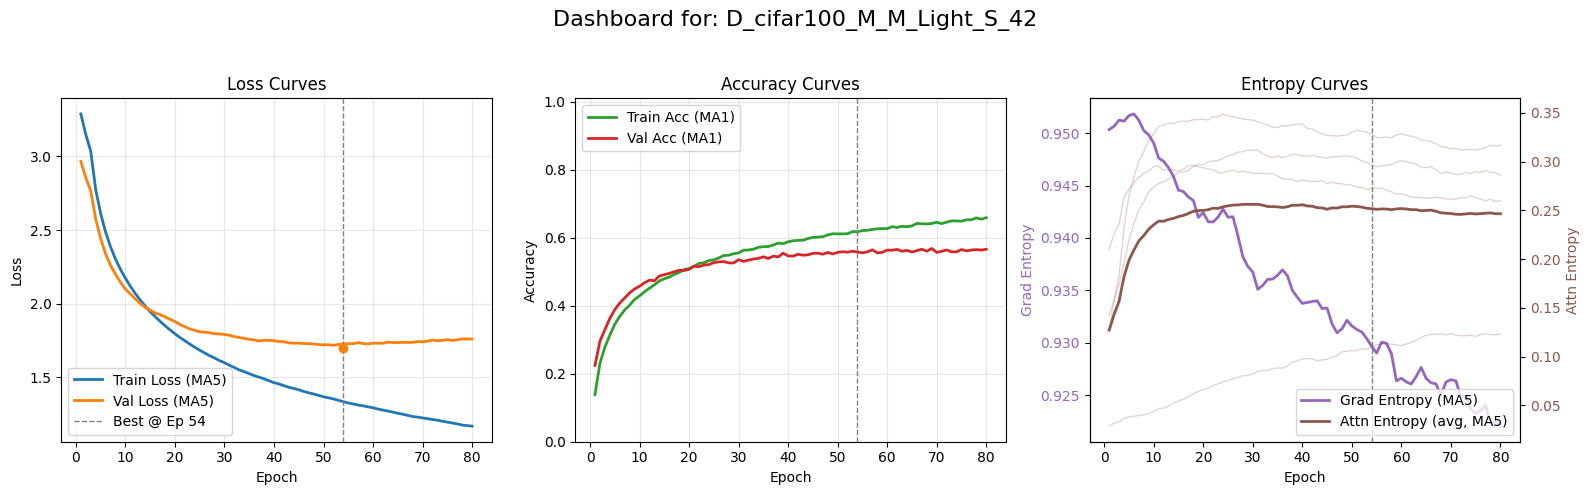

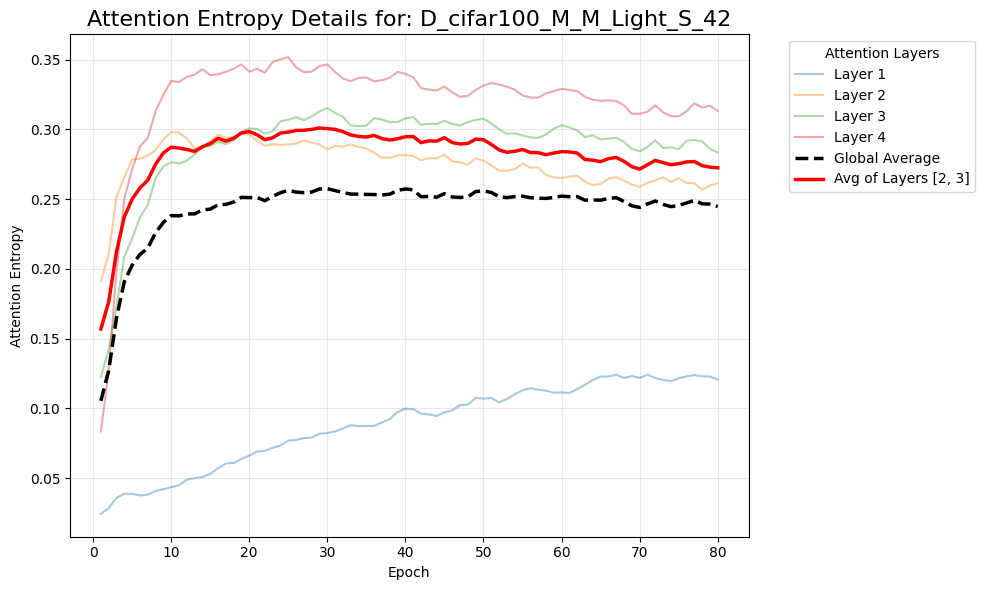

In [28]:
# ================== Plotting Driver ==================

# --- 1. Experiment to visualize ---
DATASET = "cifar100"      # 'mnist', 'cifar10', 'cifar100'
MODEL_TYPE = "M_Light"     # 'M_Light', 'M_Base', 'M_Deep', 'M_Wide'
SEED = 42
OPTIMIZER = "Adam_noWD"   # 'Adam_noWD', 'Adam_WD',


# --- 2. Automatically load and parse log file ---

experiment_stem = ""
# Check if it's the original Adam experiment without an optimizer label
if OPTIMIZER == 'Adam_noWD':
    experiment_stem = f"D_{DATASET}_M_{MODEL_TYPE}_S_{SEED}"
else:
    # For all other optimizers, use the format with 'O' label
    experiment_stem = f"D_{DATASET}_M_{MODEL_TYPE}_O_{OPTIMIZER}_S_{SEED}"

filename = f"{experiment_stem}_logs.csv"
log_path = Path(OUTPUT_ROOT) / "grid_search" / filename

print(f"Loading log file: {log_path}")

try:
    df = pd.read_csv(log_path)
    print("✅ File loaded successfully, starting plot...")

    # Extract data series from DataFrame
    train_losses = df['train_loss'].values; val_losses = df['val_loss'].values
    train_accs = df['train_acc'].values; val_accs = df['val_acc'].values
    grad_entropies = df['grad_entropy'].values; attn_entropies_avg = df['attn_entropy_avg'].values
    attn_layer_cols = sorted([col for col in df.columns if 'attn_entropy_layer_' in col])
    attn_entropies_per_layer = [df[col].values for col in attn_layer_cols]

    # --- 3. Call plotting functions ---

    # Assume plot_three_panel_training and plot_attention_entropy_details functions are already defined in your environment

    plot_three_panel_training(
        train_losses=train_losses, val_losses=val_losses,
        train_accs=train_accs, val_accs=val_accs,
        grad_entropies=grad_entropies,
        attn_entropies_avg=attn_entropies_avg,
        attn_entropies_per_layer=attn_entropies_per_layer,
        smooth_windows={'loss': 5, 'acc': 1, 'entropy': 5},
        title=f"Dashboard for: {experiment_stem}"
    )

    plot_attention_entropy_details(
        attn_entropies_avg=attn_entropies_avg,
        attn_entropies_per_layer=attn_entropies_per_layer,
        smooth_window=3,
        avg_of_layers=(1, 2), # Example
        title=f"Attention Entropy Details for: {experiment_stem}"
    )


except FileNotFoundError:
    print(f"❌ Error: Log file not found! Please confirm the configuration above is correct.")
    print(f"   - The script is looking for this file: {log_path.name}")
except Exception as e:
    print(f"❌ An unknown error occurred: {e}")

Loading log file: /content/drive/MyDrive/Colab/VisionTransformer/outputs/grid_search/D_cifar100_M_M_Light_O_Adam_WD_S_42_logs.csv
✅ File loaded successfully, starting plot...


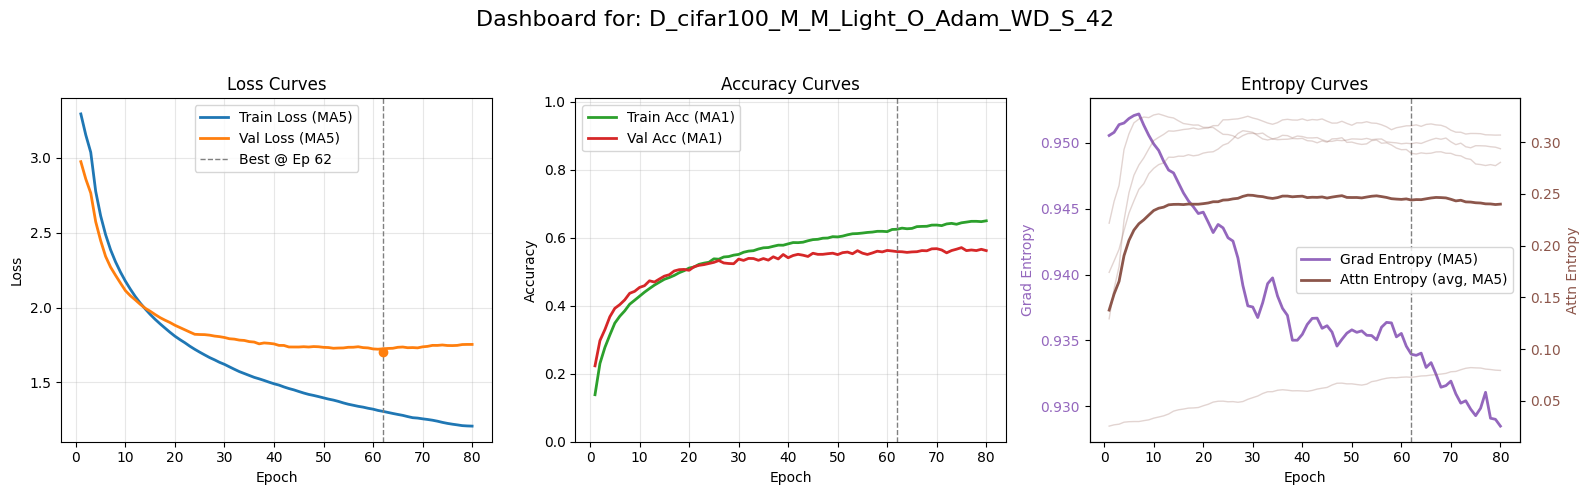

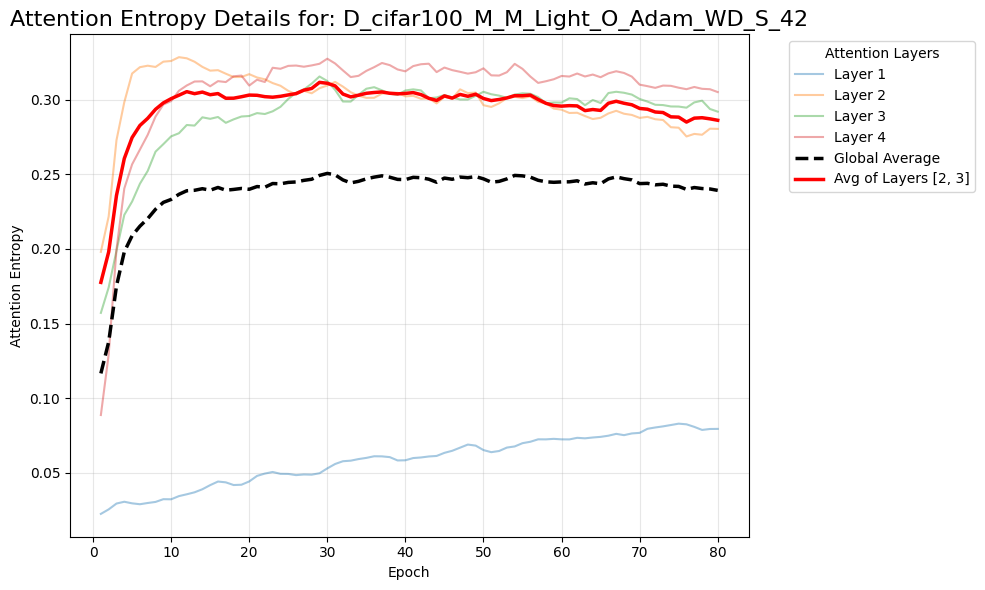

In [29]:
# ================== Plotting Driver ==================

# --- 1. Experiment to visualize ---
DATASET = "cifar100"      # 'mnist', 'cifar10', 'cifar100'
MODEL_TYPE = "M_Light"     # 'M_Light', 'M_Base', 'M_Deep', 'M_Wide'
SEED = 42
OPTIMIZER = "Adam_WD"   # 'Adam_noWD', 'Adam_WD',


# --- 2. Automatically load and parse log file ---

experiment_stem = ""
# Check if it's the original Adam experiment without an optimizer label
if OPTIMIZER == 'Adam_noWD':
    experiment_stem = f"D_{DATASET}_M_{MODEL_TYPE}_S_{SEED}"
else:
    # For all other optimizers, use the format with 'O' label
    experiment_stem = f"D_{DATASET}_M_{MODEL_TYPE}_O_{OPTIMIZER}_S_{SEED}"

filename = f"{experiment_stem}_logs.csv"
log_path = Path(OUTPUT_ROOT) / "grid_search" / filename

print(f"Loading log file: {log_path}")

try:
    df = pd.read_csv(log_path)
    print("✅ File loaded successfully, starting plot...")

    # Extract data series from DataFrame
    train_losses = df['train_loss'].values; val_losses = df['val_loss'].values
    train_accs = df['train_acc'].values; val_accs = df['val_acc'].values
    grad_entropies = df['grad_entropy'].values; attn_entropies_avg = df['attn_entropy_avg'].values
    attn_layer_cols = sorted([col for col in df.columns if 'attn_entropy_layer_' in col])
    attn_entropies_per_layer = [df[col].values for col in attn_layer_cols]

    # --- 3. Call plotting functions ---

    # Assume plot_three_panel_training and plot_attention_entropy_details functions are already defined in your environment

    plot_three_panel_training(
        train_losses=train_losses, val_losses=val_losses,
        train_accs=train_accs, val_accs=val_accs,
        grad_entropies=grad_entropies,
        attn_entropies_avg=attn_entropies_avg,
        attn_entropies_per_layer=attn_entropies_per_layer,
        smooth_windows={'loss': 5, 'acc': 1, 'entropy': 5},
        title=f"Dashboard for: {experiment_stem}"
    )

    plot_attention_entropy_details(
        attn_entropies_avg=attn_entropies_avg,
        attn_entropies_per_layer=attn_entropies_per_layer,
        smooth_window=3,
        avg_of_layers=(1, 2), # Example
        title=f"Attention Entropy Details for: {experiment_stem}"
    )


except FileNotFoundError:
    print(f"❌ Error: Log file not found! Please confirm the configuration above is correct.")
    print(f"   - The script is looking for this file: {log_path.name}")
except Exception as e:
    print(f"❌ An unknown error occurred: {e}")

Loading log file: /content/drive/MyDrive/Colab/VisionTransformer/outputs/grid_search/D_cifar100_M_M_Deep_O_Adam_WD_S_42_logs.csv
✅ File loaded successfully, starting plot...


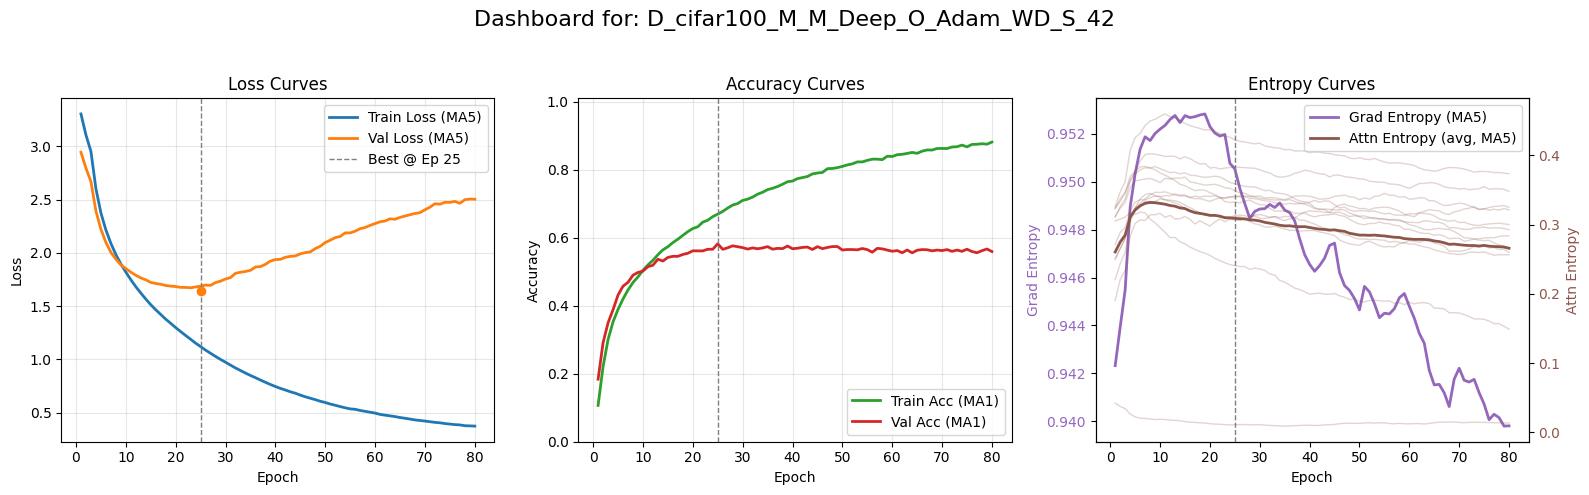

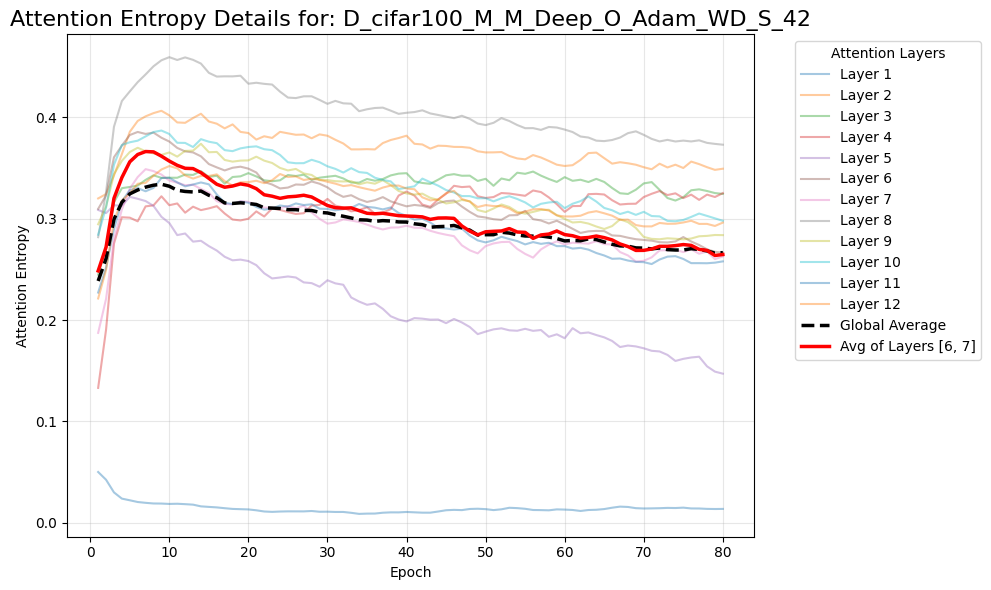

In [30]:
# ================== Plotting Driver ==================

# --- 1. Experiment to visualize ---
DATASET = "cifar100"      # 'mnist', 'cifar10', 'cifar100'
MODEL_TYPE = "M_Deep"     # 'M_Light', 'M_Base', 'M_Deep', 'M_Wide'
SEED = 42
OPTIMIZER = "Adam_WD"   # 'Adam_noWD', 'Adam_WD',


# --- 2. Automatically load and parse log file ---

experiment_stem = ""
# Check if it's the original Adam experiment without an optimizer label
if OPTIMIZER == 'Adam_noWD':
    experiment_stem = f"D_{DATASET}_M_{MODEL_TYPE}_S_{SEED}"
else:
    # For all other optimizers, use the format with 'O' label
    experiment_stem = f"D_{DATASET}_M_{MODEL_TYPE}_O_{OPTIMIZER}_S_{SEED}"

filename = f"{experiment_stem}_logs.csv"
log_path = Path(OUTPUT_ROOT) / "grid_search" / filename

print(f"Loading log file: {log_path}")

try:
    df = pd.read_csv(log_path)
    print("✅ File loaded successfully, starting plot...")

    # Extract data series from DataFrame
    train_losses = df['train_loss'].values; val_losses = df['val_loss'].values
    train_accs = df['train_acc'].values; val_accs = df['val_acc'].values
    grad_entropies = df['grad_entropy'].values; attn_entropies_avg = df['attn_entropy_avg'].values
    attn_layer_cols = sorted([col for col in df.columns if 'attn_entropy_layer_' in col])
    attn_entropies_per_layer = [df[col].values for col in attn_layer_cols]

    # --- 3. Call plotting functions ---

    # Assume plot_three_panel_training and plot_attention_entropy_details functions are already defined in your environment

    plot_three_panel_training(
        train_losses=train_losses, val_losses=val_losses,
        train_accs=train_accs, val_accs=val_accs,
        grad_entropies=grad_entropies,
        attn_entropies_avg=attn_entropies_avg,
        attn_entropies_per_layer=attn_entropies_per_layer,
        smooth_windows={'loss': 5, 'acc': 1, 'entropy': 5},
        title=f"Dashboard for: {experiment_stem}"
    )

    plot_attention_entropy_details(
        attn_entropies_avg=attn_entropies_avg,
        attn_entropies_per_layer=attn_entropies_per_layer,
        smooth_window=3,
        avg_of_layers=(5, 6), # Example
        title=f"Attention Entropy Details for: {experiment_stem}"
    )


except FileNotFoundError:
    print(f"❌ Error: Log file not found! Please confirm the configuration above is correct.")
    print(f"   - The script is looking for this file: {log_path.name}")
except Exception as e:
    print(f"❌ An unknown error occurred: {e}")

Loading log file: /content/drive/MyDrive/Colab/VisionTransformer/outputs/grid_search/D_cifar100_M_M_Wide_S_42_logs.csv
✅ File loaded successfully, starting plot...


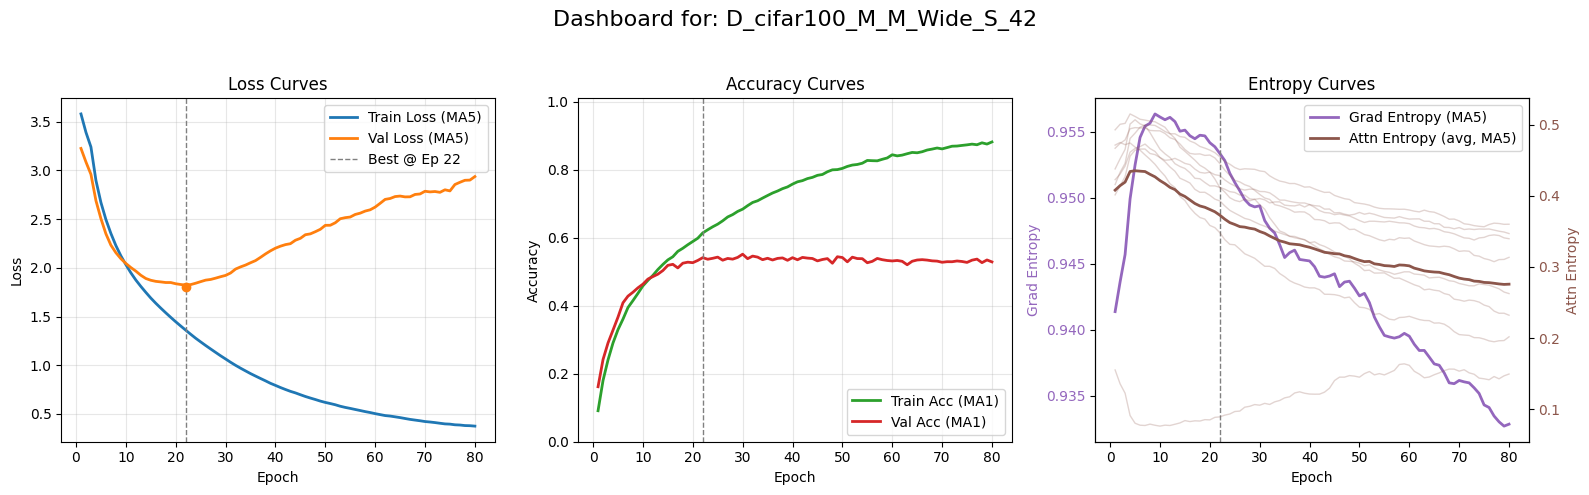

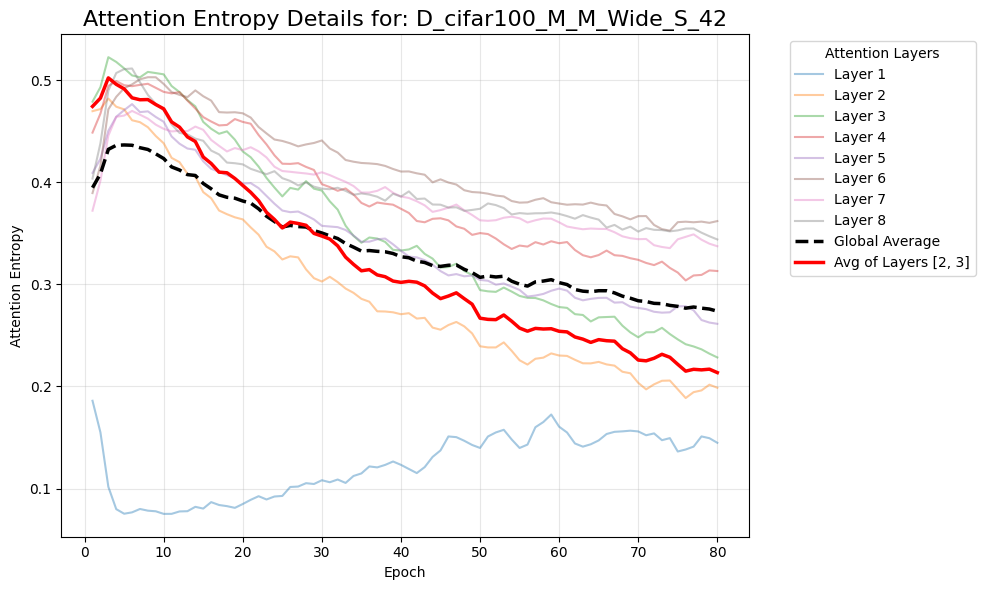

In [31]:
# ================== Plotting Driver ==================

# --- 1. Experiment to visualize ---
DATASET = "cifar100"      # 'mnist', 'cifar10', 'cifar100'
MODEL_TYPE = "M_Wide"     # 'M_Light', 'M_Base', 'M_Deep', 'M_Wide'
SEED = 42
OPTIMIZER = "Adam_noWD"   # 'Adam_noWD', 'Adam_WD',


# --- 2. Automatically load and parse log file ---

experiment_stem = ""
# Check if it's the original Adam experiment without an optimizer label
if OPTIMIZER == 'Adam_noWD':
    experiment_stem = f"D_{DATASET}_M_{MODEL_TYPE}_S_{SEED}"
else:
    # For all other optimizers, use the format with 'O' label
    experiment_stem = f"D_{DATASET}_M_{MODEL_TYPE}_O_{OPTIMIZER}_S_{SEED}"

filename = f"{experiment_stem}_logs.csv"
log_path = Path(OUTPUT_ROOT) / "grid_search" / filename

print(f"Loading log file: {log_path}")

try:
    df = pd.read_csv(log_path)
    print("✅ File loaded successfully, starting plot...")

    # Extract data series from DataFrame
    train_losses = df['train_loss'].values; val_losses = df['val_loss'].values
    train_accs = df['train_acc'].values; val_accs = df['val_acc'].values
    grad_entropies = df['grad_entropy'].values; attn_entropies_avg = df['attn_entropy_avg'].values
    attn_layer_cols = sorted([col for col in df.columns if 'attn_entropy_layer_' in col])
    attn_entropies_per_layer = [df[col].values for col in attn_layer_cols]

    # --- 3. Call plotting functions ---

    # Assume plot_three_panel_training and plot_attention_entropy_details functions are already defined in your environment

    plot_three_panel_training(
        train_losses=train_losses, val_losses=val_losses,
        train_accs=train_accs, val_accs=val_accs,
        grad_entropies=grad_entropies,
        attn_entropies_avg=attn_entropies_avg,
        attn_entropies_per_layer=attn_entropies_per_layer,
        smooth_windows={'loss': 5, 'acc': 1, 'entropy': 5},
        title=f"Dashboard for: {experiment_stem}"
    )

    plot_attention_entropy_details(
        attn_entropies_avg=attn_entropies_avg,
        attn_entropies_per_layer=attn_entropies_per_layer,
        smooth_window=3,
        avg_of_layers=(1, 2), # Example
        title=f"Attention Entropy Details for: {experiment_stem}"
    )


except FileNotFoundError:
    print(f"❌ Error: Log file not found! Please confirm the configuration above is correct.")
    print(f"   - The script is looking for this file: {log_path.name}")
except Exception as e:
    print(f"❌ An unknown error occurred: {e}")

In [32]:
# ================== CELL A: Early Stopping Calculation and Plotting Function Library (Final Complete Version) ==================

import pandas as pd
import numpy as np
from scipy.stats import theilslopes
from collections import deque
from glob import glob
from pathlib import Path
import matplotlib.pyplot as plt

# --- Calculation Functions for Strategies 1-4 ---
def robust_slope(y):
    if y is None or len(y) < 2: return 0.0
    slope, _, _, _ = theilslopes(y, np.arange(len(y)))
    return slope if np.isfinite(slope) else 0.0

def calculate_loss_stop_epoch(log_df, patience=10, min_delta=0.002, min_epochs=20):
    if len(log_df) < min_epochs: return None
    best_val_loss, wait = float('inf'), 0
    for i, row in log_df.iterrows():
        epoch, current_val_loss = row['epoch'], row['val_loss']
        if current_val_loss < best_val_loss * (1 - min_delta): best_val_loss, wait = current_val_loss, 0
        else: wait += 1
        if epoch >= min_epochs and wait >= patience: return epoch
    return None

def calculate_grad_entropy_stop_epoch(log_df, patience=10, min_delta=0.002, min_epochs=20, entropy_window=8, entropy_slope_eps=1e-3):
    if len(log_df) < min_epochs: return None
    best_val_loss, wait = float('inf'), 0; entropy_hist = deque(maxlen=entropy_window)
    for i, row in log_df.iterrows():
        epoch, cvl, ge = row['epoch'], row['val_loss'], row['grad_entropy']
        entropy_hist.append(ge)
        if cvl < best_val_loss * (1 - min_delta): best_val_loss, wait = cvl, 0
        else: wait += 1
        if epoch >= min_epochs:
            cond_patience = (wait >= patience)
            cond_entropy_trend = False
            if len(entropy_hist) == entropy_window and abs(robust_slope(list(entropy_hist))) < entropy_slope_eps: cond_entropy_trend = True
            if cond_patience and cond_entropy_trend: return epoch
    return None

def calculate_global_attn_stop_epoch(log_df, patience=10, min_delta=0.002, min_epochs=20, entropy_window=8, entropy_slope_eps=1e-3):
    if len(log_df) < min_epochs: return None
    if 'attn_entropy_avg' not in log_df.columns: return "Missing Column"
    global_attn_entropy = log_df['attn_entropy_avg']
    best_val_loss, wait = float('inf'), 0; entropy_hist = deque(maxlen=entropy_window)
    for i, row in log_df.iterrows():
        epoch, cvl, cae = row['epoch'], row['val_loss'], global_attn_entropy[i]
        entropy_hist.append(cae)
        if cvl < best_val_loss * (1 - min_delta): best_val_loss, wait = cvl, 0
        else: wait += 1
        if epoch >= min_epochs:
            cond_patience = (wait >= patience)
            cond_entropy_trend = False
            if len(entropy_hist) == entropy_window and abs(robust_slope(list(entropy_hist))) < entropy_slope_eps: cond_entropy_trend = True
            if cond_patience and cond_entropy_trend: return epoch
    return None

def calculate_mid_layer_attn_stop_epoch(log_df, mid_layers, patience=10, min_delta=0.002, min_epochs=20, entropy_window=8, entropy_slope_eps=1e-3):
    if len(log_df) < min_epochs: return None
    layer_cols = [f'attn_entropy_layer_{i+1}' for i in mid_layers]
    missing_cols = [col for col in layer_cols if col not in log_df.columns]
    if missing_cols: return f"Missing Layers"
    mid_layer_attn_entropy = log_df[layer_cols].mean(axis=1)
    best_val_loss, wait = float('inf'), 0
    entropy_hist = deque(maxlen=entropy_window)
    for i, row in log_df.iterrows():
        epoch, current_val_loss, current_attn_entropy = row['epoch'], row['val_loss'], mid_layer_attn_entropy[i]
        entropy_hist.append(current_attn_entropy)
        if current_val_loss < best_val_loss * (1 - min_delta): best_val_loss, wait = current_val_loss, 0
        else: wait += 1
        if epoch >= min_epochs:
            cond_patience = (wait >= patience)
            cond_entropy_trend = False
            if len(entropy_hist) == entropy_window and abs(robust_slope(list(entropy_hist))) < entropy_slope_eps: cond_entropy_trend = True
            if cond_patience and cond_entropy_trend: return epoch
    return None


def _ma_same(x, w=3):
    x = np.asarray(x, dtype=float)
    if w is None or w <= 1 or x.size < 2: return x
    return np.convolve(x, np.ones(w)/w, mode="same")

def _pick_layers(n_layers, layers):
    if isinstance(layers, (tuple, list, np.ndarray)): idx = list(map(int, layers))
    elif layers == 'mid2': mid = n_layers // 2; idx = [max(0, mid-1), min(n_layers-1, mid)]
    elif layers == 'mid1': idx = [n_layers // 2]
    elif layers == 'all': idx = list(range(n_layers))
    else: raise ValueError(f"Unrecognized layers: {layers}")
    idx = sorted(set([i for i in idx if 0 <= i < n_layers]))
    if not idx: raise ValueError("No valid layer indices.")
    return idx

def detect_stages_anydrop_then_overfit(logs, layers='mid2', use="auto", warmup_epochs=1, drop_min_abs=0.0, drop_min_rel=0.0, smooth_w=5, plateau_win=10, plateau_std_thresh=1.0e-3, plateau_grad_thresh=1.0e-3, slope_thresh=-5e-4, slope_patience=10, min_gap=1, s1_fallback_ratio=0.20, s2_fallback_ratio=0.70):
    attn_layers = logs.get("attn_entropies_per_layer"); attn_avg = logs.get("attn_entropies_avg")
    source = "per_layer" if (attn_layers and any(len(x) > 0 for x in attn_layers)) else ("avg" if (attn_avg and len(attn_avg) > 0) else None)
    if source is None: raise ValueError("No attention entropy sequence available.")
    if source == "per_layer":
        n_layers = len(attn_layers); T = min(len(x) for x in attn_layers if x is not None and len(x) > 0)
        layer_idx = _pick_layers(n_layers, layers)
        if not all(len(attn_layers[li]) >= T for li in layer_idx): raise ValueError("Log length not sufficient for some layers")
        mid_raw = np.array([np.mean([float(attn_layers[li][ep]) for li in layer_idx]) for ep in range(T)], dtype=float)
    else:
        mid_raw = np.asarray(attn_avg, dtype=float); T = mid_raw.size; layer_idx = None
    if T <= max(2, warmup_epochs): return {"s1_epoch": T, "s2_epoch": T}
    epochs_arr = logs.get("epochs", list(range(1, T + 1)))
    mid_sm = _ma_same(mid_raw, smooth_w)
    s1_idx, trig1, delta = None, "fallback", None
    for i in range(max(1, int(warmup_epochs)), T):
        d = mid_raw[i] - mid_raw[i-1]
        cond = (d < 0.0) and (abs(d) >= drop_min_abs) and (abs(d) >= drop_min_rel * max(abs(mid_raw[i-1]), 1e-12))
        if cond: s1_idx, trig1, delta = i, "any_raw_drop", float(d); break
    if s1_idx is None: s1_idx = int(T * s1_fallback_ratio); delta = float('nan')
    def is_plateau_at(idx):
        seg = mid_sm[idx: idx + plateau_win]
        if seg.size < plateau_win: return False
        return bool(np.std(seg) < plateau_std_thresh and np.mean(np.abs(np.gradient(seg))) < plateau_grad_thresh)
    earliest = max(s1_idx + int(min_gap), 0); s2_plateau = None; s2_drop, cnt = None, 0
    for i in range(earliest, T - plateau_win + 1):
        if is_plateau_at(i): s2_plateau = i; break
    drops = np.diff(mid_sm)
    for j in range(max(earliest, 1), drops.size):
        if drops[j] <= slope_thresh:
            cnt += 1
            if cnt >= slope_patience: s2_drop = j - slope_patience + 1; break
        else: cnt = 0
    if s2_plateau is not None and s2_drop is not None: s2_idx, trig2 = (s2_plateau, "smooth_plateau") if s2_plateau <= s2_drop else (s2_drop, "smooth_drop")
    elif s2_plateau is not None: s2_idx, trig2 = s2_plateau, "smooth_plateau"
    elif s2_drop is not None: s2_idx, trig2 = s2_drop, "smooth_drop"
    else: s2_idx, trig2 = max(s1_idx + int(min_gap), int(T * s2_fallback_ratio)), "fallback"
    return {"s1_epoch": int(epochs_arr[s1_idx]), "s2_epoch": int(epochs_arr[min(s2_idx, T - 1)])}

def calculate_attn_stages_epochs(log_df, **kwargs):
    logs_dict = {'epochs': log_df['epoch'].tolist(), 'attn_entropies_avg': log_df['attn_entropy_avg'].tolist()}
    attn_layer_cols = sorted([col for col in log_df.columns if 'attn_entropy_layer_' in col])
    logs_dict['attn_entropies_per_layer'] = [log_df[col].tolist() for col in attn_layer_cols]
    try:
        det = detect_stages_anydrop_then_overfit(logs_dict, **kwargs)
        return det['s1_epoch'], det['s2_epoch']
    except Exception: return "Detection Failed", "Detection Failed"

print("✅ Early stopping and stage analysis function library updated, including all strategies.")

✅ Early stopping and stage analysis function library updated, including all strategies.


In [33]:
# ================== CELL B: Analysis and Report Generator (Final Complete Version) ==================

# --- 1. Configure parameters for all strategies ---
loss_stop_config = {"patience": 10, "min_delta": 0.002, "min_epochs": 20}
entropy_stop_config = {"patience": 10, "min_delta": 0.002, "min_epochs": 20, "entropy_window": 8, "entropy_slope_eps": 1e-3}
MID_LAYERS_CONFIG = {"M_Light": (1, 2), "M_Base": (3, 4), "M_Deep": (5, 6), "M_Wide": (3, 4)}
stage_detection_config = {"layers": 'mid2', "smooth_w": 5, "warmup_epochs": 20, "drop_min_rel": 0.01, "plateau_std_thresh": 1e-3, "slope_thresh": -5e-4}

In [34]:
from tqdm import tqdm
# --- 2. Automatically scan, load, and analyze all log files ---
log_dir = Path(OUTPUT_ROOT) / "grid_search"
all_log_files = sorted(glob(str(log_dir / "D_*.csv")))
analysis_results = []

print(f"Analyzing {len(all_log_files)} log files...")

if not all_log_files:
    print("⚠️ No log files found.")
else:
    for f in tqdm(all_log_files, desc="Analyzing Logs"):
        try:
            log_df = pd.read_csv(f)

            # Parse filename
            parts = Path(f).stem.replace('_logs','').split('_')
            summary = {}
            idx_M, idx_S = parts.index('M'), parts.index('S')
            summary['dataset'], summary['seed'] = parts[1], int(parts[idx_S + 1])
            if 'O' in parts:
                idx_O = parts.index('O')
                summary['model_type'] = '_'.join(parts[idx_M + 1 : idx_O])
                summary['optimizer'] = '_'.join(parts[idx_O + 1 : idx_S])
            else:
                summary['model_type'] = '_'.join(parts[idx_M + 1 : idx_S])
                summary['optimizer'] = 'Adam_noWD'

            # --- [Restored and Integrated] Call all calculation functions ---
            loss_stop = calculate_loss_stop_epoch(log_df, **loss_stop_config)
            grad_entropy_stop = calculate_grad_entropy_stop_epoch(log_df, **entropy_stop_config)
            global_attn_stop = calculate_global_attn_stop_epoch(log_df, **entropy_stop_config)

            model_key = summary['model_type']
            mid_layers_to_use = MID_LAYERS_CONFIG.get(model_key)
            mid_attn_entropy_stop = calculate_mid_layer_attn_stop_epoch(log_df, mid_layers=mid_layers_to_use, **entropy_stop_config)

            s1_epoch, s2_epoch = calculate_attn_stages_epochs(log_df, **stage_detection_config)

            summary['total_epochs'] = len(log_df)
            summary['best_acc_epoch'] = int(log_df.loc[log_df['val_acc'].idxmax()]['epoch'])
            summary['loss_stop_epoch'] = loss_stop if loss_stop is not None else 'Not Triggered'
            summary['grad_entropy_stop_epoch'] = grad_entropy_stop if grad_entropy_stop is not None else 'Not Triggered'
            summary['global_attn_stop_epoch'] = global_attn_stop if global_attn_stop is not None else 'Not Triggered'
            summary['mid_attn_stop_epoch'] = mid_attn_entropy_stop if mid_attn_entropy_stop is not None else 'Not Triggered' # <-- Restored
            summary['attn_stage1_epoch'] = s1_epoch
            summary['attn_stage2_epoch'] = s2_epoch
            analysis_results.append(summary)

        except Exception as e:
            print(f"\nError processing file {Path(f).name}: {e}. Skipped.\n")
            continue

Analyzing 120 log files...


Analyzing Logs: 100%|██████████| 120/120 [00:35<00:00,  3.42it/s]


In [35]:
# --- 3. Format and print the results report ---
if analysis_results:
    results_df = pd.DataFrame(analysis_results)
    print("\n\n--- Early Stopping and Stage Analysis Report (Final Complete Version) ---")

    column_order = ['dataset', 'model_type', 'optimizer', 'seed', 'total_epochs', 'best_acc_epoch',
                    'loss_stop_epoch', 'grad_entropy_stop_epoch', 'global_attn_stop_epoch',
                    'mid_attn_stop_epoch', 'attn_stage1_epoch', 'attn_stage2_epoch']
    results_df = results_df[column_order]

    print(results_df.sort_values(by=['optimizer', 'dataset', 'model_type', 'seed']).to_string())



--- Early Stopping and Stage Analysis Report (Final Complete Version) ---
      dataset model_type  optimizer  seed  total_epochs  best_acc_epoch loss_stop_epoch grad_entropy_stop_epoch global_attn_stop_epoch mid_attn_stop_epoch  attn_stage1_epoch  attn_stage2_epoch
42    cifar10     M_Base    Adam_WD    16            60              54            47.0                    47.0                   47.0                58.0                 23                 43
44    cifar10     M_Base    Adam_WD    42            60              45            55.0                    55.0                   56.0                55.0                 21                 43
41    cifar10     M_Base    Adam_WD   123            60              59            49.0                    49.0                   49.0                49.0                 21                 38
40    cifar10     M_Base    Adam_WD  1234            60              48            47.0                    47.0                   58.0                58